## SALES FORECASTING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("Sales_forecasting_Corrected.xlsx")

# Exploratory Data Analysis

In [3]:
df.head()

,Row_ID,Date,Product_ID,Product_Name,Category,Store_ID,Store_Location,Units_Sold,Price,Discount_Percentage,...,Season,Weather,Local_Event_Flag,Competitor_Price,Economic_Indicator,Sales_Channel,Customer_Segment,Marketing_Spend,Week_of_Year,Is_Weekday
0,1,2023-01-06,P002,Bluetooth Speaker,Electronics,S01,Chennai,54,3763.742294,0,...,Winter,Sunny,1,3454.023813,100.942142,Online,Retail,0.000000,1,1
1,2,2023-01-13,P002,Bluetooth Speaker,Electronics,S01,Chennai,58,3763.712176,0,...,Winter,Sunny,1,3446.529758,100.941796,Online,Retail,0.000000,2,1
2,3,2023-01-28,P002,Bluetooth Speaker,Electronics,S01,Chennai,64,2398.777773,8,...,Winter,Sunny,1,2266.365488,98.543457,In-Store,Retail,8410.202040,4,0
3,4,2023-02-09,P005,LED Desk Lamp,Home,S04,Delhi,96,1406.019435,20,...,Winter,Sunny,0,1493.410240,95.786449,In-Store,Retail,6880.514325,6,1
4,5,2023-02-13,P006,Running Shoes,Apparel,S02,Bengaluru,45,3337.215178,6,...,Winter,Rainy,0,3100.272443,106.214774,Wholesale,Corporate,7908.876991,7,1


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 3000
Number of columns: 29


In [5]:
df.columns

Index(['Row_ID', 'Date', 'Product_ID', 'Product_Name', 'Category', 'Store_ID',
       'Store_Location', 'Units_Sold', 'Price', 'Discount_Percentage',
       'Revenue', 'Promotion_Flag', 'Stock_Availability', 'Day_of_Week',
       'Month', 'Quarter', 'Holiday_Flag', 'Holiday_Name', 'Is_Weekend',
       'Season', 'Weather', 'Local_Event_Flag', 'Competitor_Price',
       'Economic_Indicator', 'Sales_Channel', 'Customer_Segment',
       'Marketing_Spend', 'Week_of_Year', 'Is_Weekday'],
      dtype='str')

In [6]:
df.dtypes

Row_ID                          int64
Date                   datetime64[us]
Product_ID                        str
Product_Name                      str
Category                          str
Store_ID                          str
Store_Location                    str
Units_Sold                      int64
Price                         float64
Discount_Percentage             int64
Revenue                       float64
Promotion_Flag                  int64
Stock_Availability              int64
Day_of_Week                       str
Month                             str
Quarter                           str
Holiday_Flag                    int64
Holiday_Name                      str
Is_Weekend                      int64
Season                            str
Weather                           str
Local_Event_Flag                int64
Competitor_Price              float64
Economic_Indicator            float64
Sales_Channel                     str
Customer_Segment                  str
Marketing_Sp

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Row_ID               3000 non-null   int64         
 1   Date                 3000 non-null   datetime64[us]
 2   Product_ID           3000 non-null   str           
 3   Product_Name         3000 non-null   str           
 4   Category             3000 non-null   str           
 5   Store_ID             3000 non-null   str           
 6   Store_Location       3000 non-null   str           
 7   Units_Sold           3000 non-null   int64         
 8   Price                3000 non-null   float64       
 9   Discount_Percentage  3000 non-null   int64         
 10  Revenue              3000 non-null   float64       
 11  Promotion_Flag       3000 non-null   int64         
 12  Stock_Availability   3000 non-null   int64         
 13  Day_of_Week          3000 non-null   str    

In [8]:
df.isnull().sum()

Row_ID                    0
Date                      0
Product_ID                0
Product_Name              0
Category                  0
Store_ID                  0
Store_Location            0
Units_Sold                0
Price                     0
Discount_Percentage       0
Revenue                   0
Promotion_Flag            0
Stock_Availability        0
Day_of_Week               0
Month                     0
Quarter                   0
Holiday_Flag              0
Holiday_Name           2951
Is_Weekend                0
Season                    0
Weather                   0
Local_Event_Flag          0
Competitor_Price          0
Economic_Indicator        0
Sales_Channel             0
Customer_Segment          0
Marketing_Spend           0
Week_of_Year              0
Is_Weekday                0
dtype: int64

In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage[missing_percentage > 0])

Holiday_Name    98.366667
dtype: float64


In [10]:
df['Holiday_Name'] = df['Holiday_Name'].fillna('No govt holiday')

In [11]:
df['Holiday_Name'].isnull().sum()

np.int64(0)

In [12]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [13]:
df.describe()

,Row_ID,Date,Units_Sold,Price,Discount_Percentage,Revenue,Promotion_Flag,Stock_Availability,Holiday_Flag,Is_Weekend,Local_Event_Flag,Competitor_Price,Economic_Indicator,Marketing_Spend,Week_of_Year,Is_Weekday
count,3000.000000,3000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,2024-12-25 22:29:16.800000,42.068667,2573.711019,7.901333,85526.327757,0.713000,0.782000,0.016333,0.291000,0.219333,2576.519046,102.957429,3948.421185,26.809000,0.709000
min,1.000000,2023-01-06 00:00:00,0.000000,201.882929,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,178.622136,94.704011,0.000000,1.000000,0.000000
25%,750.750000,2024-06-08 00:00:00,15.000000,1291.656025,0.000000,26357.575000,0.000000,1.000000,0.000000,0.000000,0.000000,1294.086406,99.236747,584.781483,14.000000,0.000000
50%,1500.500000,2024-12-21 00:00:00,43.000000,2548.635583,5.000000,72796.025000,1.000000,1.000000,0.000000,0.000000,0.000000,2551.171348,103.326410,3658.554202,27.000000,1.000000
75%,2250.250000,2025-07-19 00:00:00,64.000000,3773.608720,15.000000,135340.352500,1.000000,1.000000,0.000000,1.000000,0.000000,3747.301655,106.640194,6681.394113,40.000000,1.000000
max,3000.000000,2026-12-25 00:00:00,121.000000,4995.614847,24.000000,308494.850000,1.000000,1.000000,1.000000,1.000000,1.000000,5321.850000,110.391935,10378.057840,52.000000,1.000000
std,866.169729,NaN,29.250319,1395.352185,7.542274,67527.276922,0.452437,0.412956,0.126775,0.454299,0.413864,1409.036602,4.322717,3251.426886,14.914467,0.454299


In [14]:
df.describe(include='object')

C:\Users\Nishanth\AppData\Local\Temp\ipykernel_5636\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Product_ID,Product_Name,Category,Store_ID,Store_Location,Day_of_Week,Month,Quarter,Holiday_Name,Season,Weather,Sales_Channel,Customer_Segment
count,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000
unique,8,8,7,4,4,7,12,4,7,4,5,3,3
top,P005,LED Desk Lamp,Electronics,S01,Chennai,Saturday,October,Q2,No govt holiday,Monsoon,Sunny,Wholesale,Corporate
freq,408,408,688,833,833,479,277,768,2951,1023,675,1045,1020


In [15]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print("\n", col)
    print(df[col].unique())


 Product_ID
<StringArray>
['P002', 'P005', 'P006', 'P004', 'P001', 'P007', 'P008', 'P003']
Length: 8, dtype: str

 Product_Name
<StringArray>
['Bluetooth Speaker',     'LED Desk Lamp',     'Running Shoes',
     'Notebook Pack',    'Wireless Mouse',          'Yoga Mat',
      'Coffee Maker',      'Office Chair']
Length: 8, dtype: str

 Category
<StringArray>
['Electronics',        'Home',     'Apparel',  'Stationery',      'Sports',
  'Appliances',   'Furniture']
Length: 7, dtype: str

 Store_ID
<StringArray>
['S01', 'S04', 'S02', 'S03']
Length: 4, dtype: str

 Store_Location
<StringArray>
['Chennai', 'Delhi', 'Bengaluru', 'Mumbai']
Length: 4, dtype: str

 Day_of_Week
<StringArray>
['Friday', 'Saturday', 'Thursday', 'Monday', 'Tuesday', 'Wednesday', 'Sunday']
Length: 7, dtype: str

 Month
<StringArray>
[  'January',  'February',     'March',     'April',       'May',      'June',
      'July',    'August', 'September',   'October',  'November',  'December']
Length: 12, dtype: str

 Qua

C:\Users\Nishanth\AppData\Local\Temp\ipykernel_5636\3990991152.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [16]:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].nunique())


Row_ID:
3000

Date:
1077

Product_ID:
8

Product_Name:
8

Category:
7

Store_ID:
4

Store_Location:
4

Units_Sold:
119

Price:
3000

Discount_Percentage:
25

Revenue:
2908

Promotion_Flag:
2

Stock_Availability:
2

Day_of_Week:
7

Month:
12

Quarter:
4

Holiday_Flag:
2

Holiday_Name:
7

Is_Weekend:
2

Season:
4

Weather:
5

Local_Event_Flag:
2

Competitor_Price:
3000

Economic_Indicator:
2852

Sales_Channel:
3

Customer_Segment:
3

Marketing_Spend:
2856

Week_of_Year:
52

Is_Weekday:
2


In [17]:
df['Date'] = pd.to_datetime(df['Date'])

In [18]:
print(df['Date'].min())
print(df['Date'].max())

2023-01-06 00:00:00
2026-12-25 00:00:00


In [19]:
print("Minimum:", df['Units_Sold'].min())
print("Maximum:", df['Units_Sold'].max())
print("Mean:", df['Units_Sold'].mean())
print("Median:", df['Units_Sold'].median())

Minimum: 0
Maximum: 121
Mean: 42.068666666666665
Median: 43.0


Univariate Analysis

In [20]:
# Identify Numerical Columns

numerical_columns = df.select_dtypes(
    include=['int64', 'float64']
).columns

print(numerical_columns)

Index(['Row_ID', 'Units_Sold', 'Price', 'Discount_Percentage', 'Revenue',
       'Promotion_Flag', 'Stock_Availability', 'Holiday_Flag', 'Is_Weekend',
       'Local_Event_Flag', 'Competitor_Price', 'Economic_Indicator',
       'Marketing_Spend', 'Week_of_Year', 'Is_Weekday'],
      dtype='str')


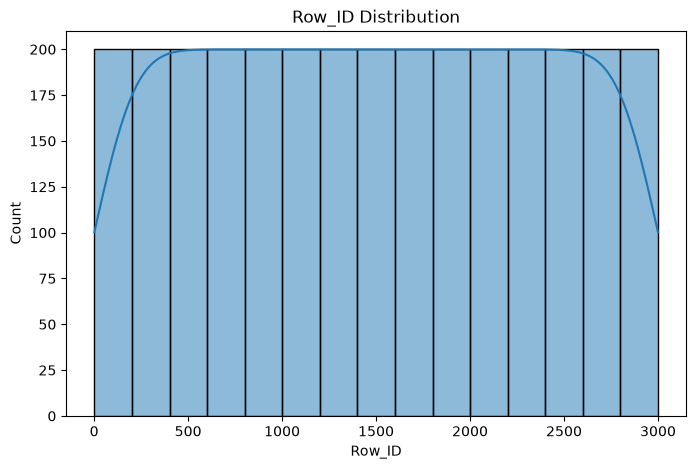

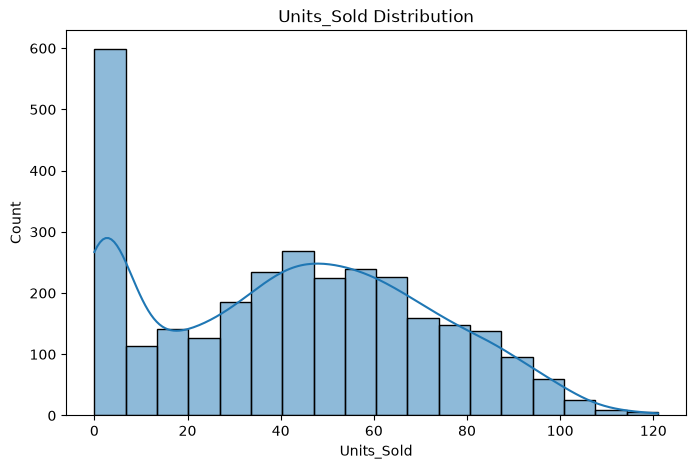

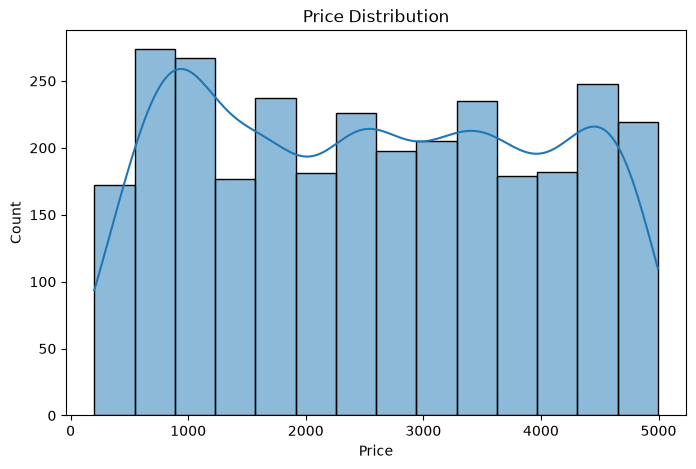

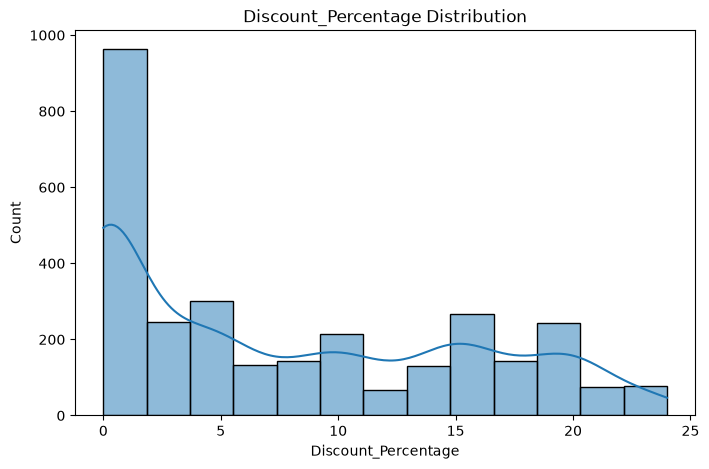

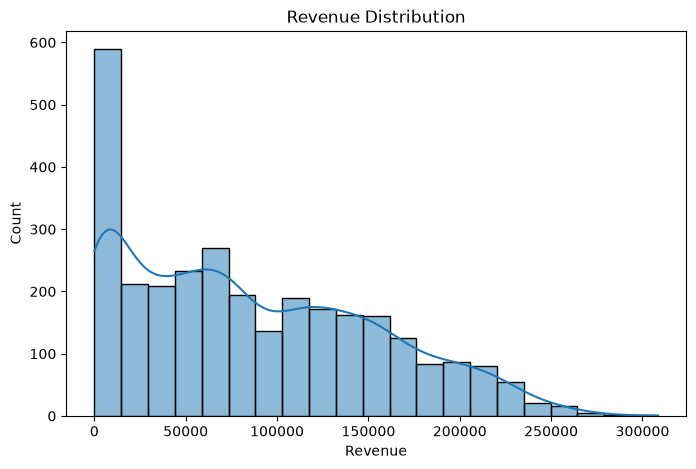

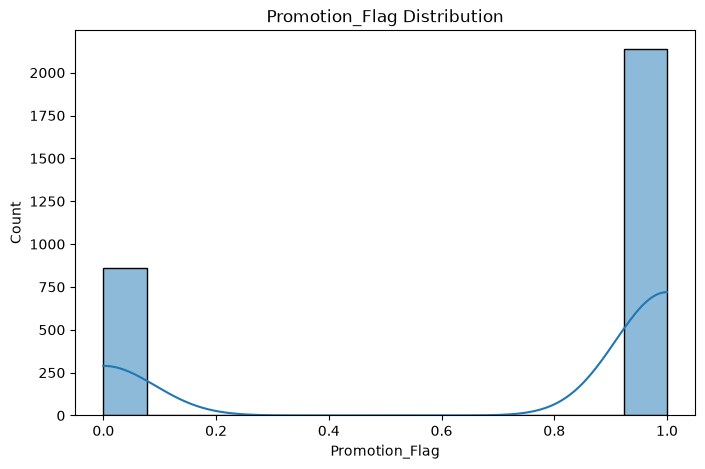

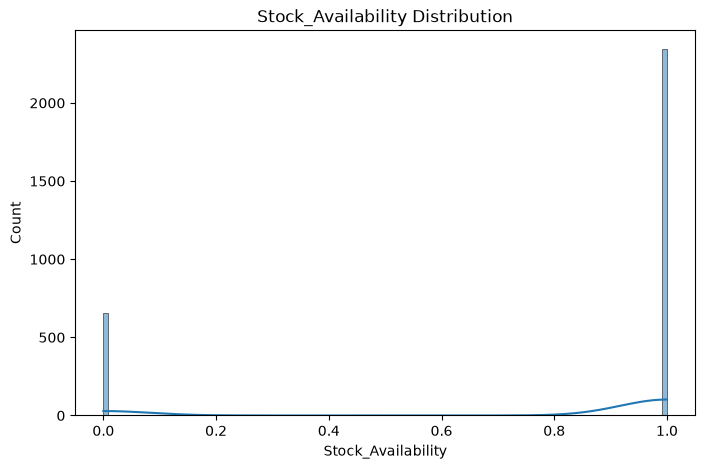

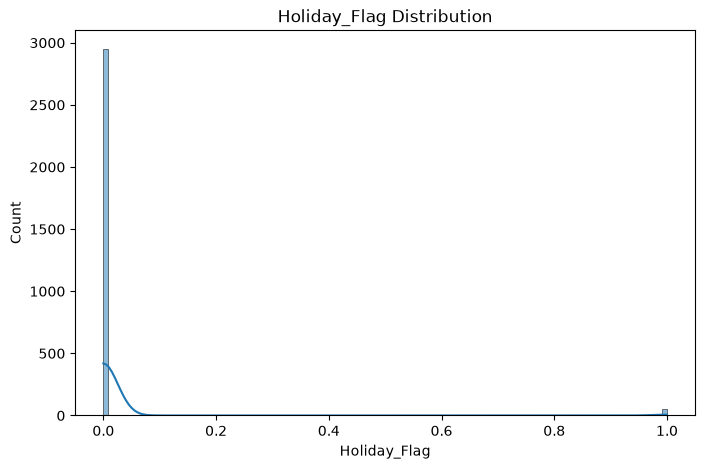

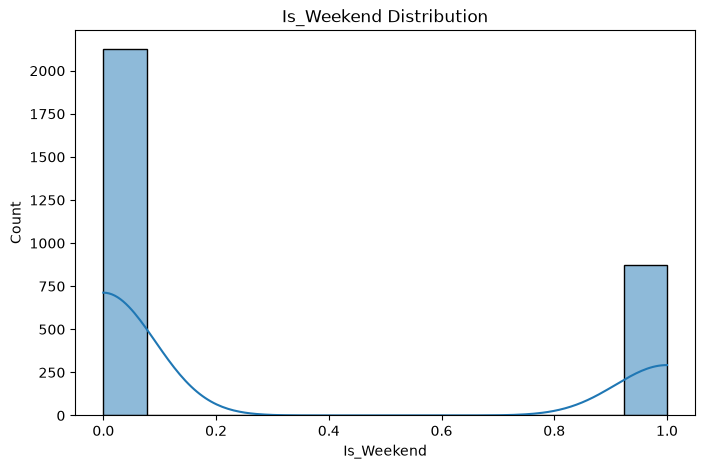

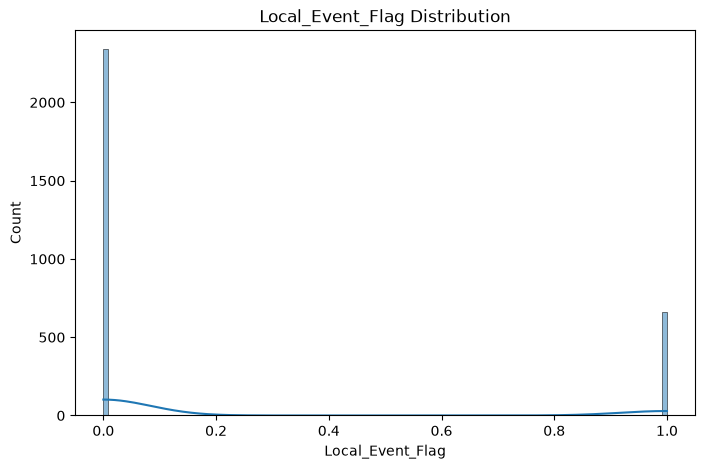

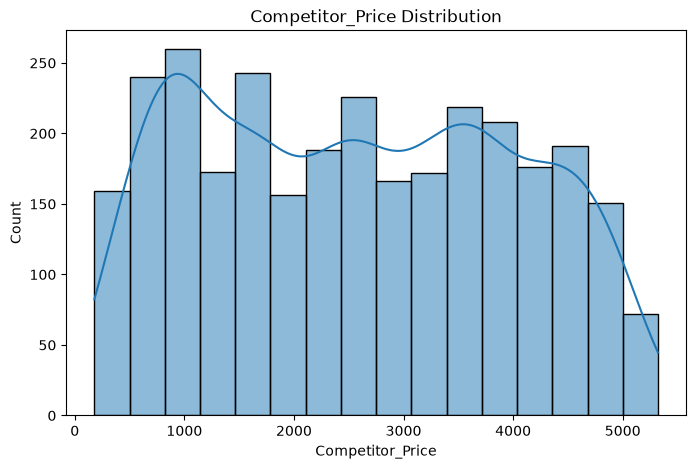

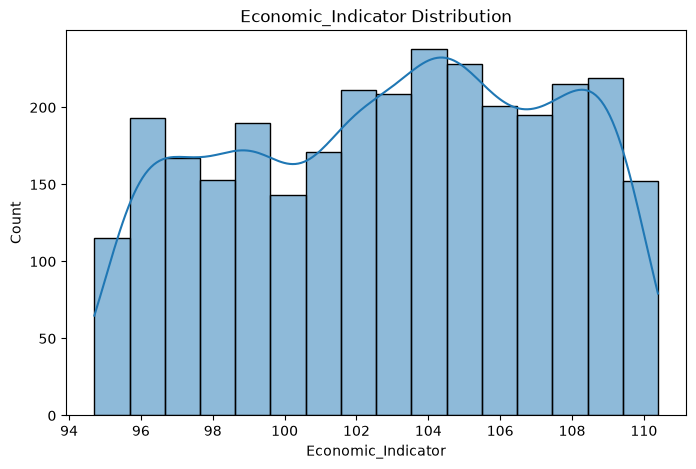

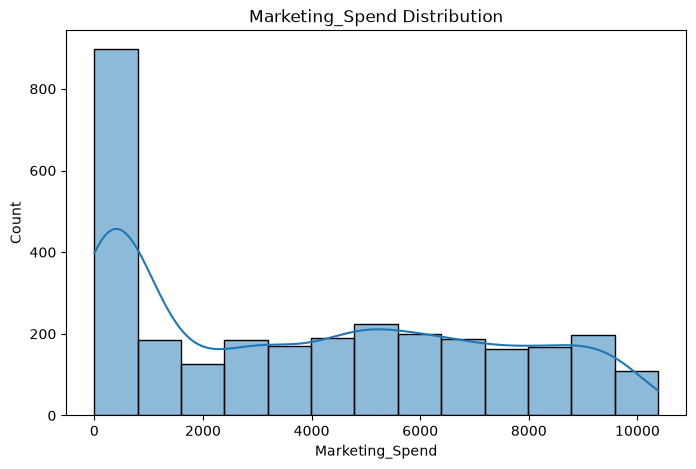

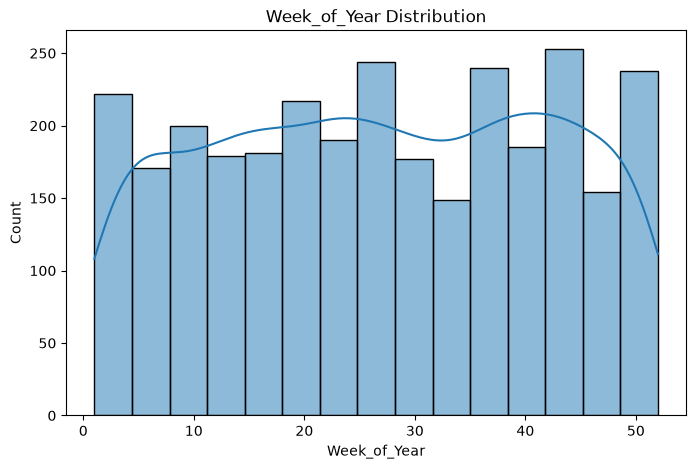

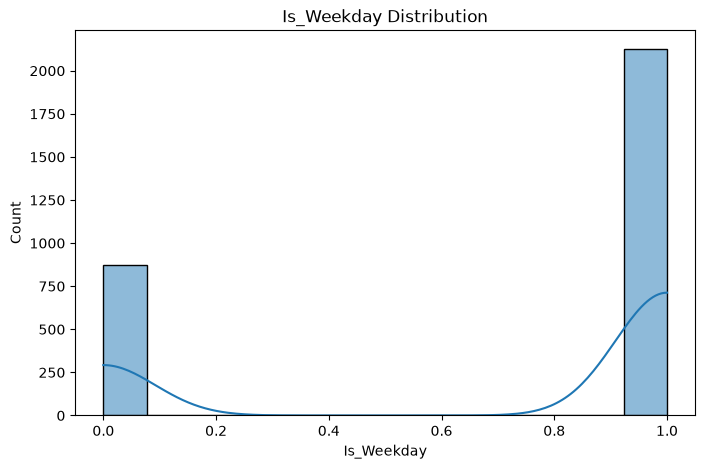

In [21]:
# Numerical Feature Distributions

for col in numerical_columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [22]:
categorical_columns = df.select_dtypes(
    include=['object']
).columns

print(categorical_columns)

Index(['Product_ID', 'Product_Name', 'Category', 'Store_ID', 'Store_Location',
       'Day_of_Week', 'Month', 'Quarter', 'Holiday_Name', 'Season', 'Weather',
       'Sales_Channel', 'Customer_Segment'],
      dtype='str')


C:\Users\Nishanth\AppData\Local\Temp\ipykernel_5636\2340610171.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


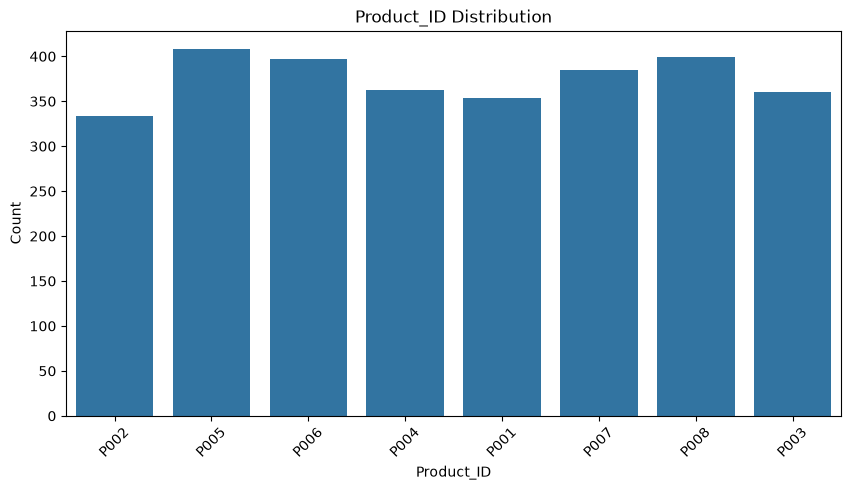

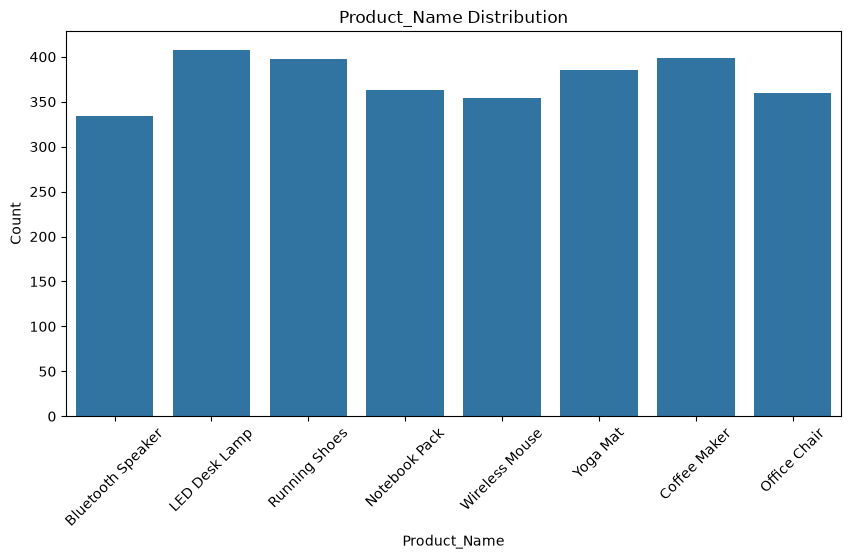

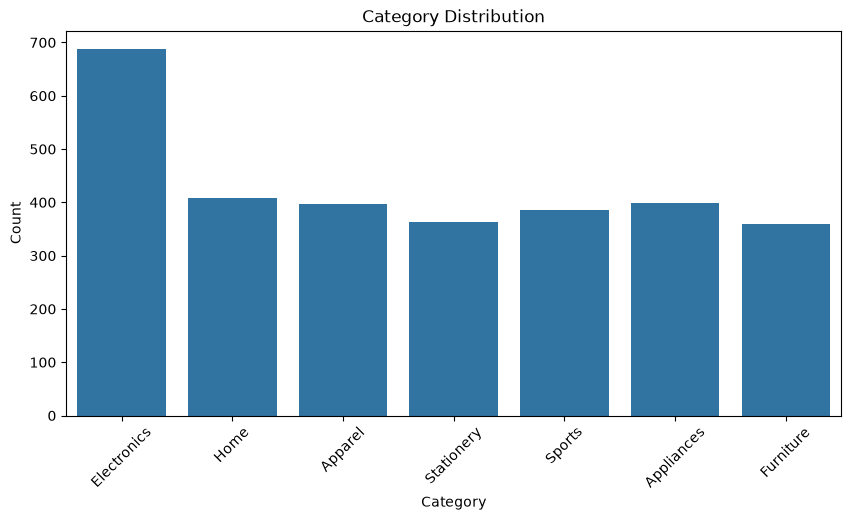

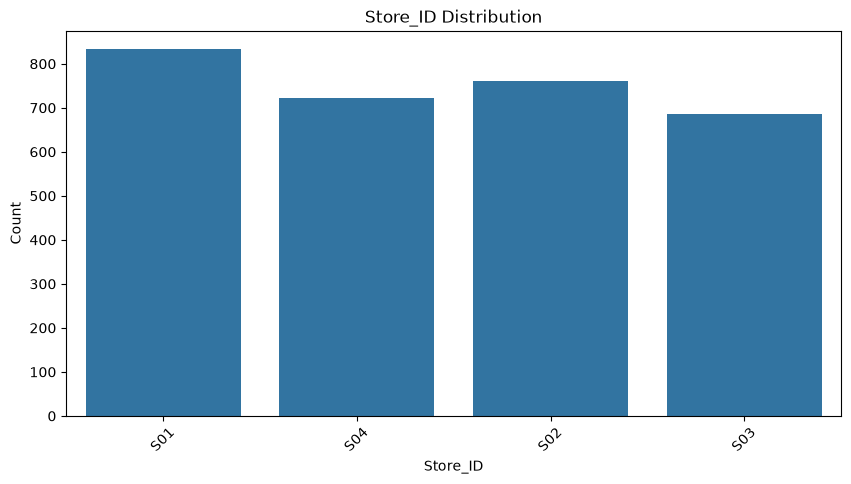

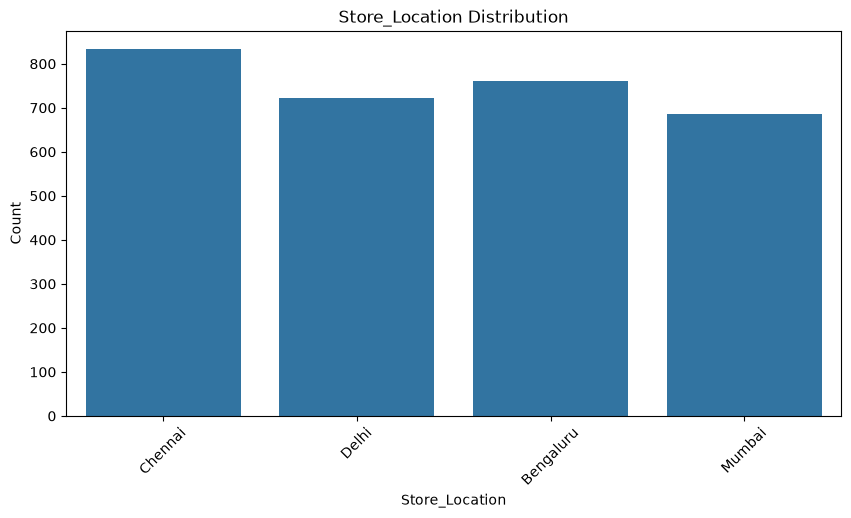

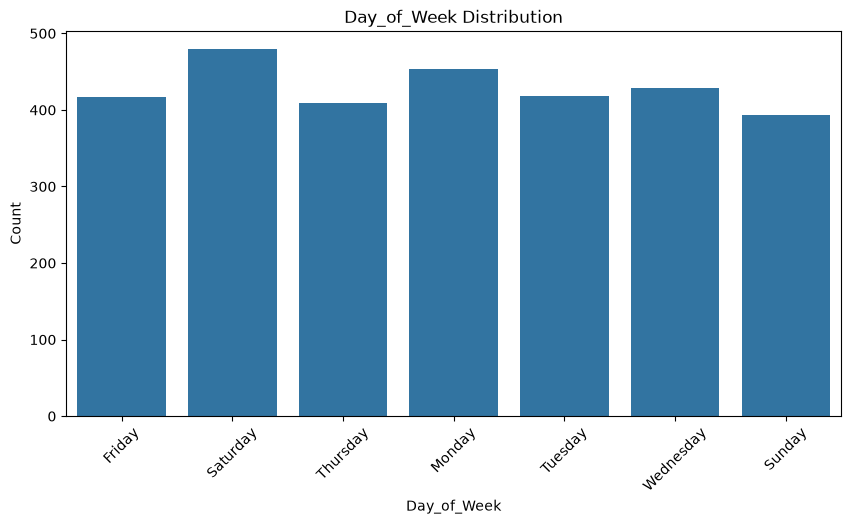

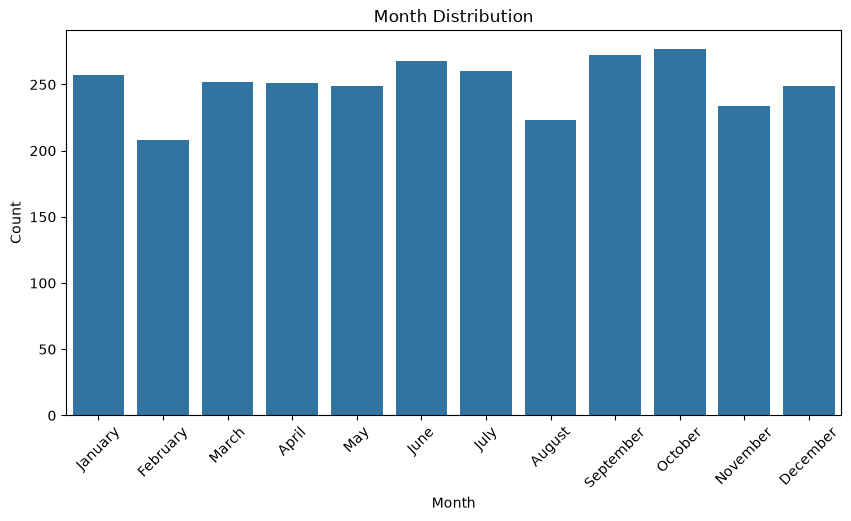

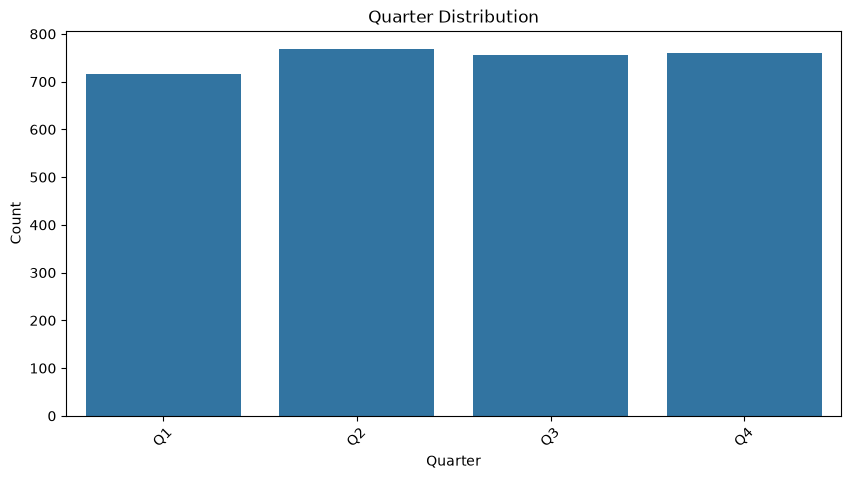

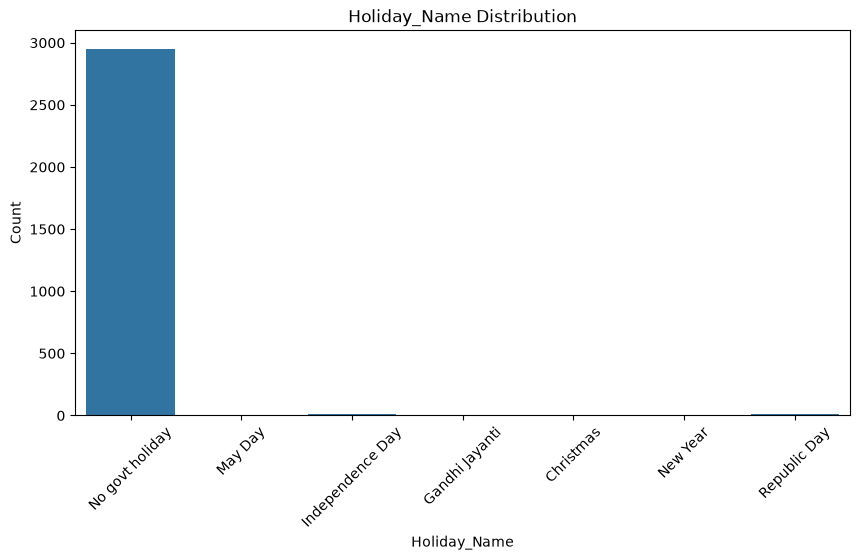

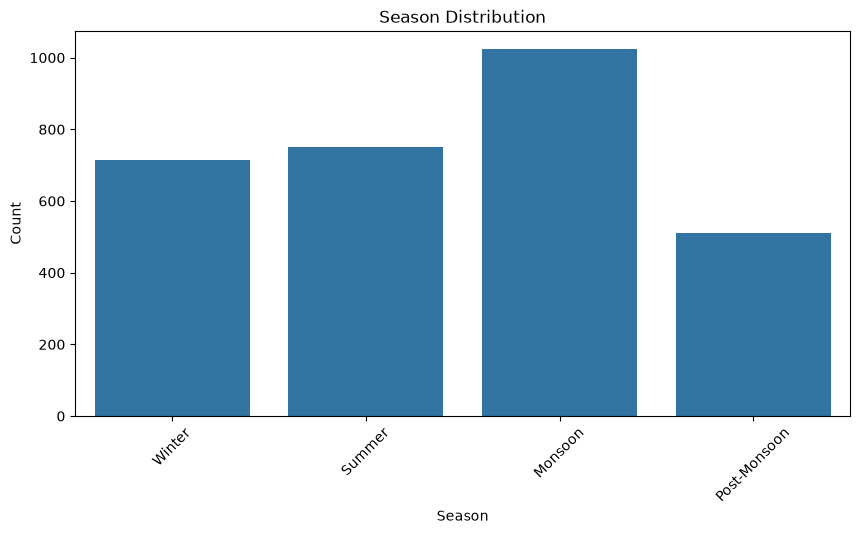

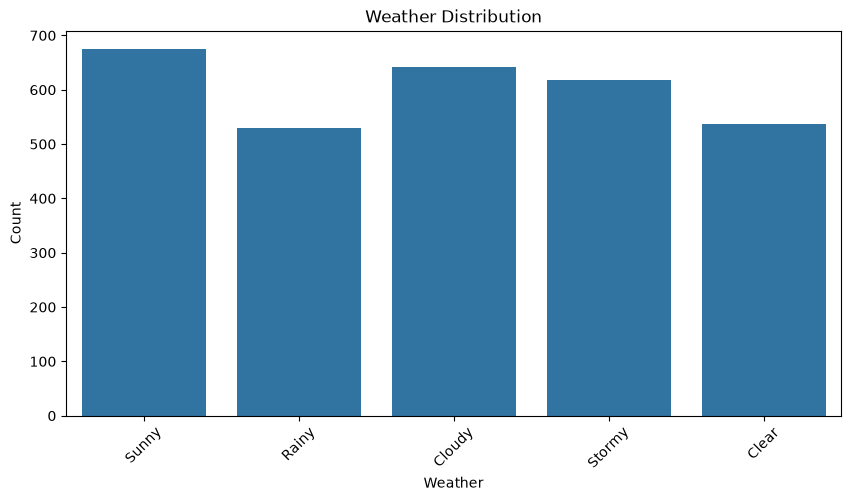

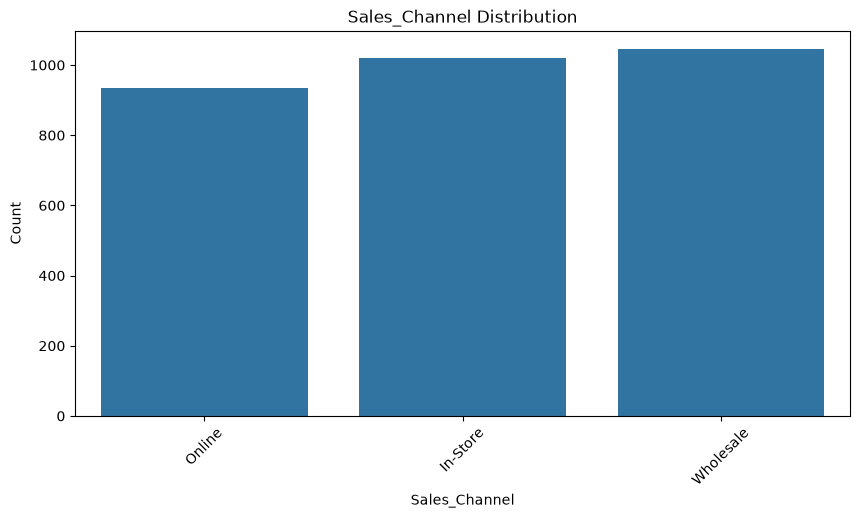

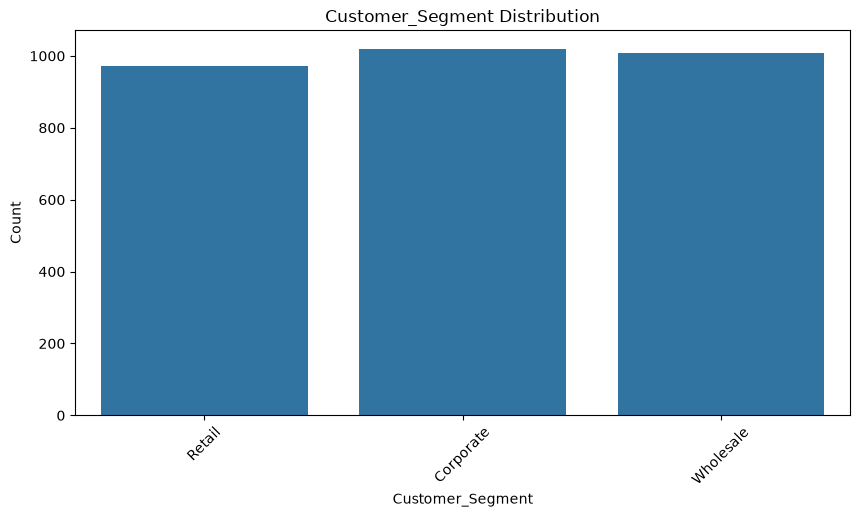

In [23]:
# Cartegorical features distributions

for col in categorical_columns:
    plt.figure(figsize=(10, 5))
    
    sns.countplot(data=df, x=col)
    
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

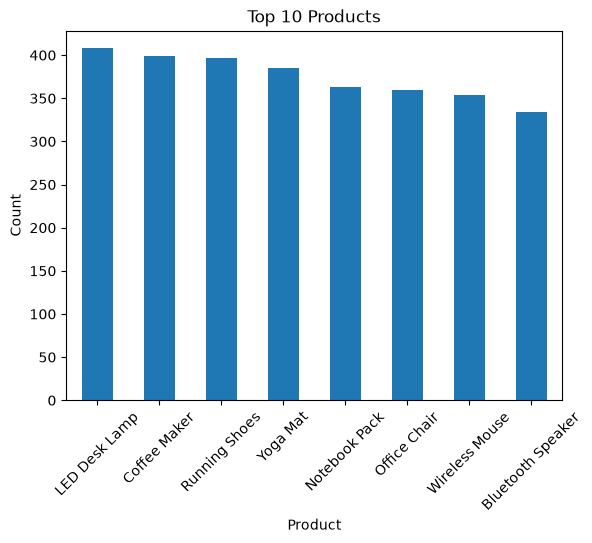

In [24]:
# Top 10 Products

df['Product_Name'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Products")
plt.xlabel("Product")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Bivariate Analysis

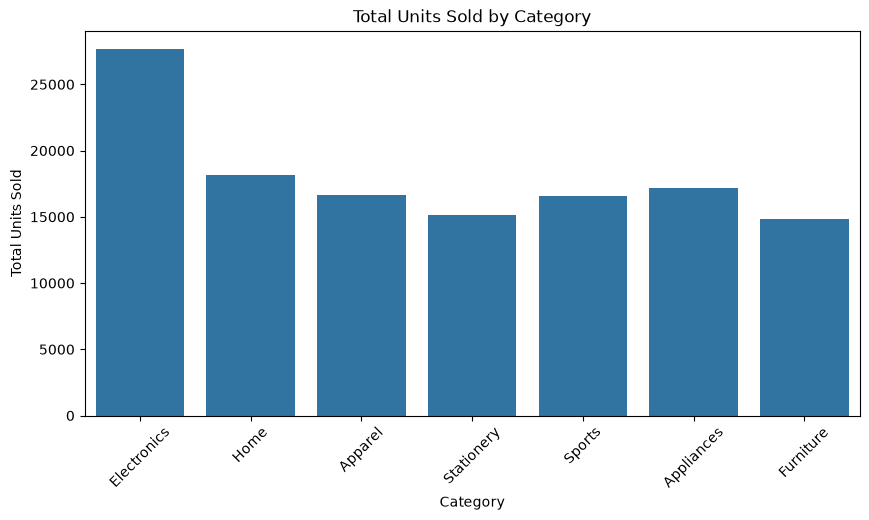

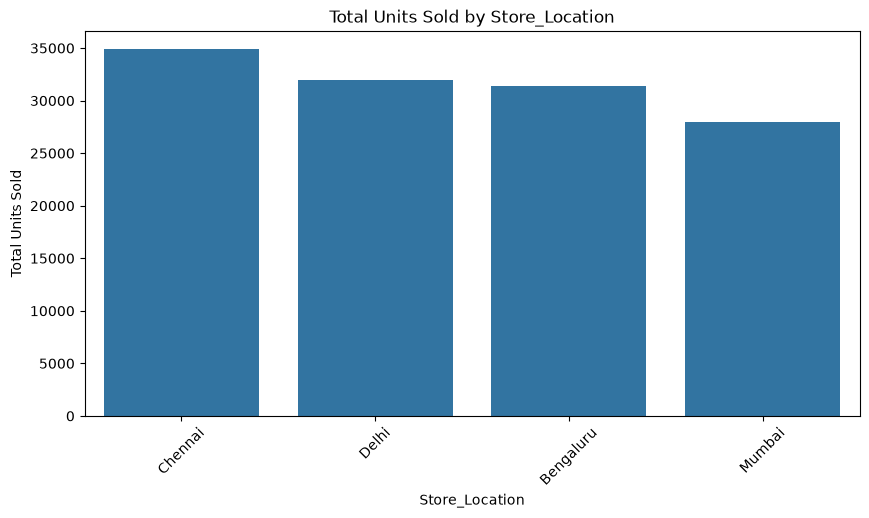

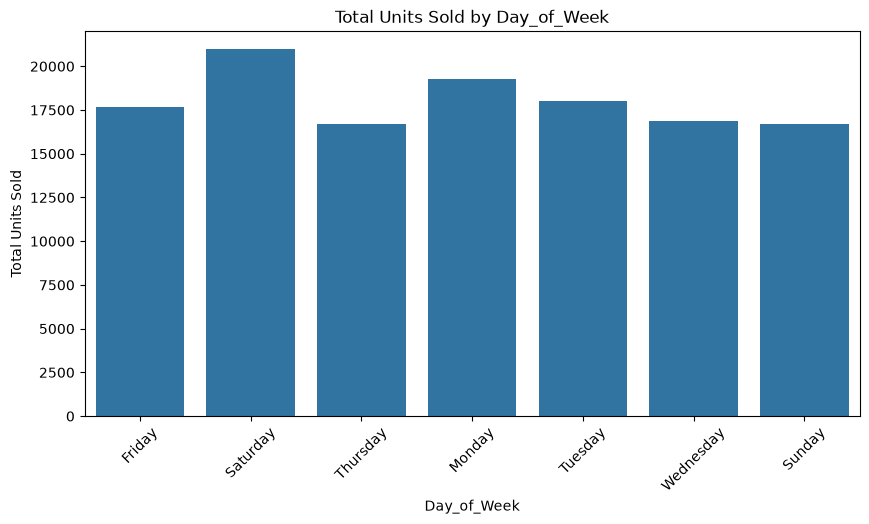

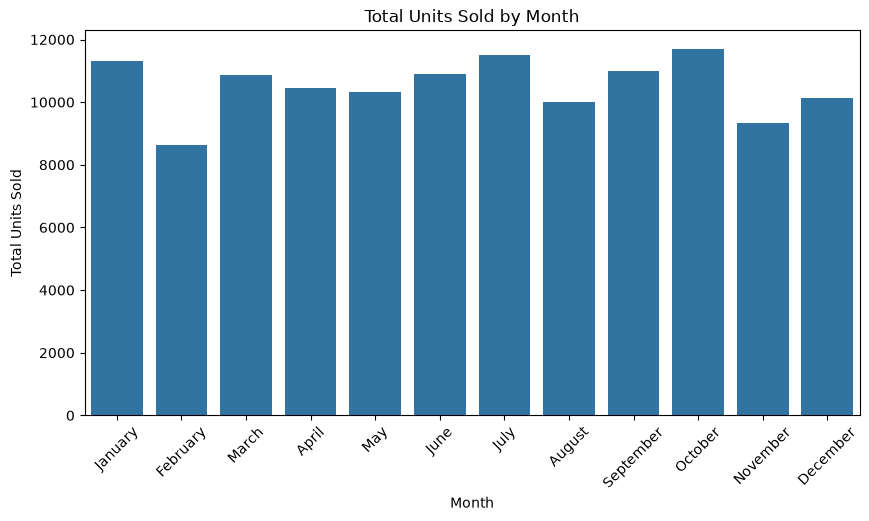

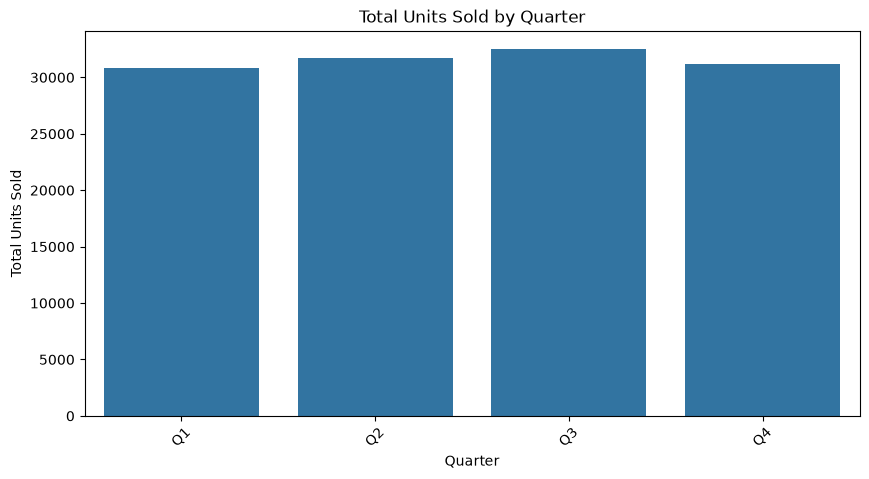

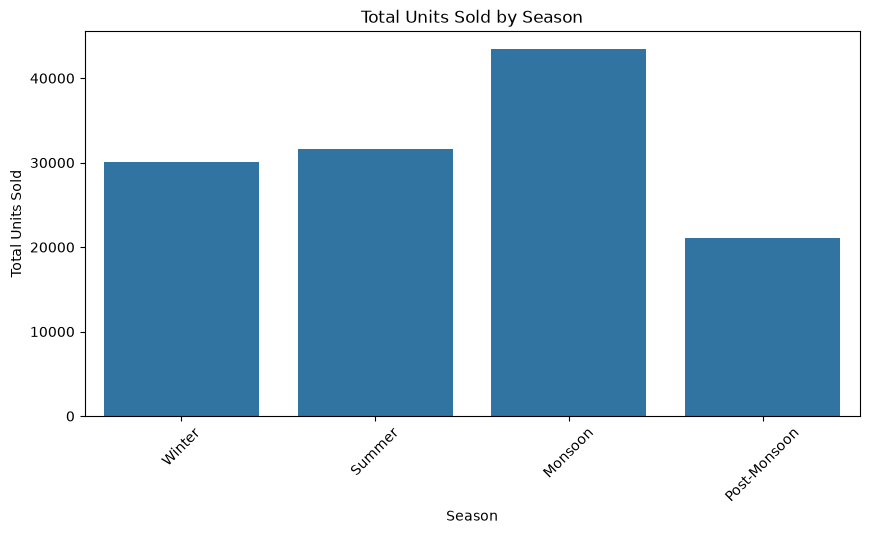

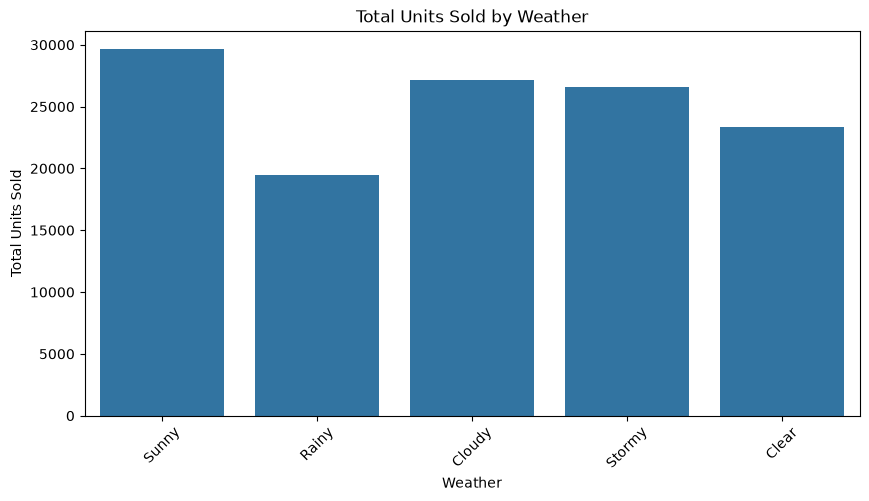

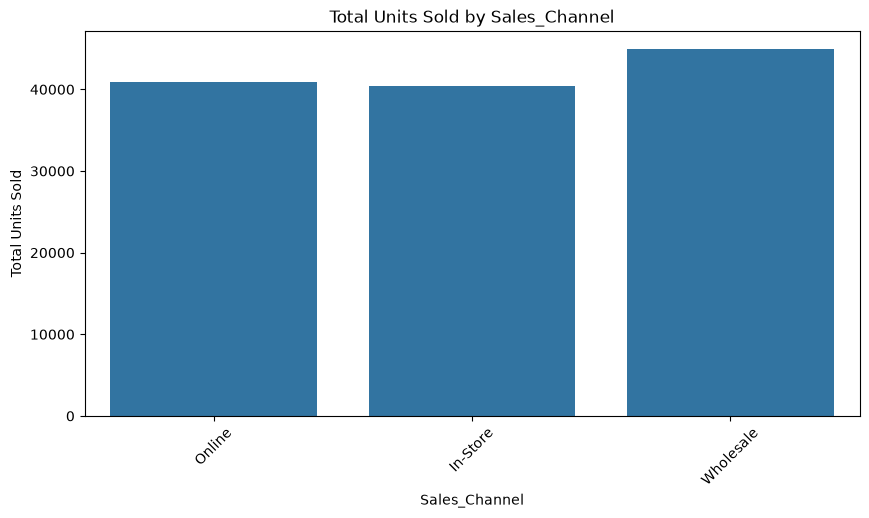

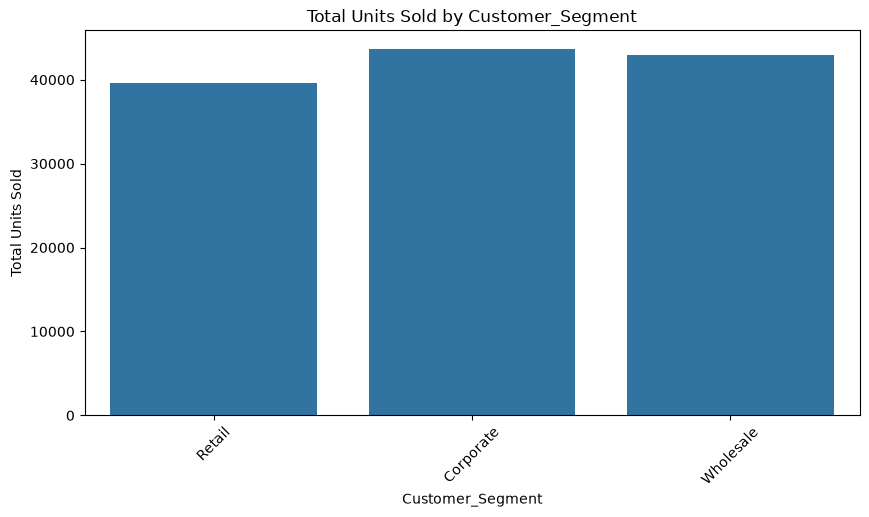

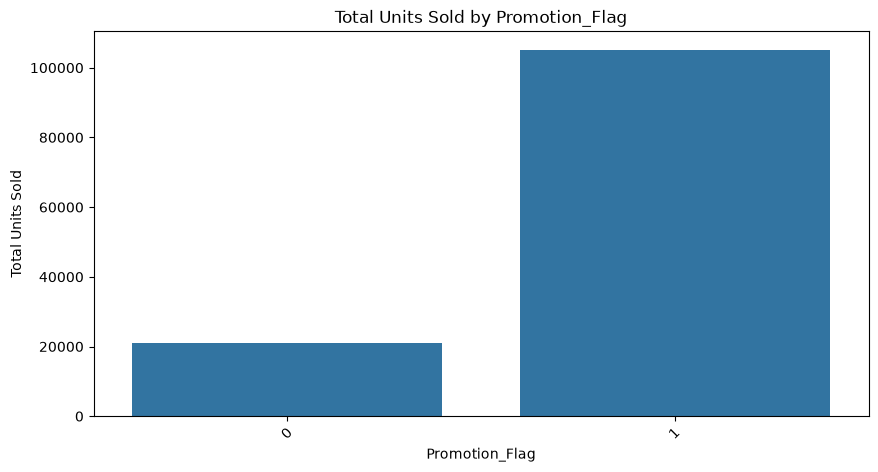

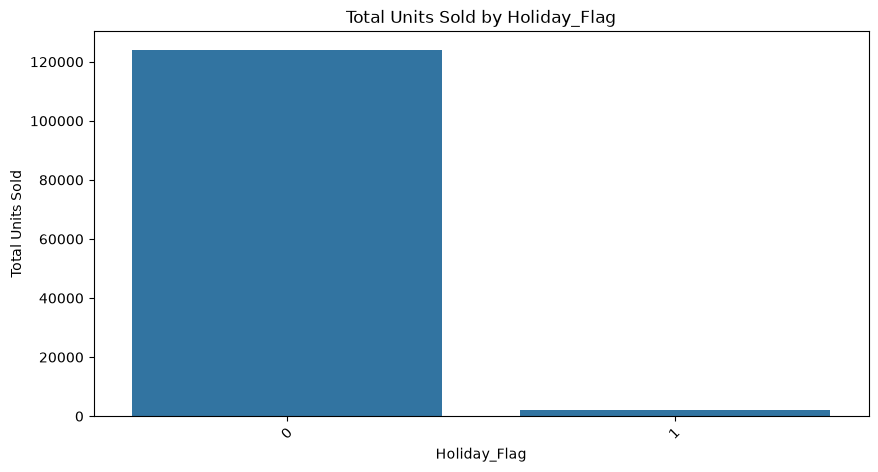

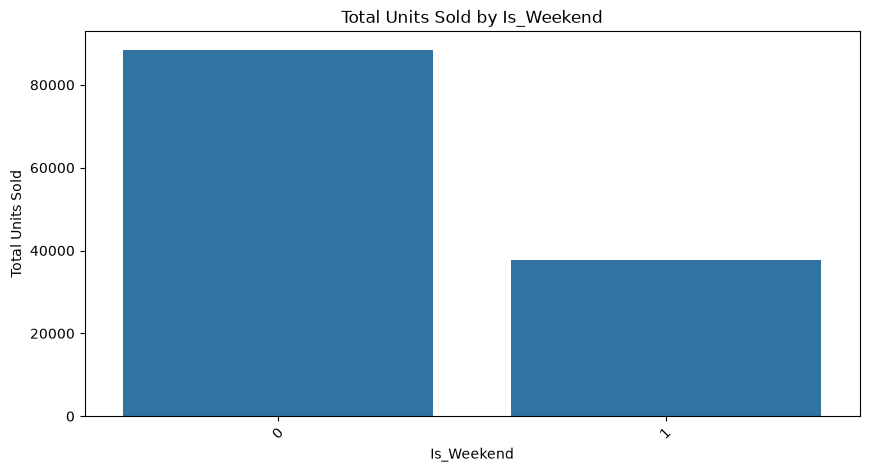

In [25]:
categorical_features = [
    'Category',
    'Store_Location',
    'Day_of_Week',
    'Month',
    'Quarter',
    'Season',
    'Weather',
    'Sales_Channel',
    'Customer_Segment',
    'Promotion_Flag',
    'Holiday_Flag',
    'Is_Weekend'
]

for col in categorical_features:
    plt.figure(figsize=(10, 5))
    
    sns.barplot(
        data=df,
        x=col,
        y='Units_Sold',
        estimator=sum,
        errorbar=None
    )
    
    plt.title(f"Total Units Sold by {col}")
    plt.xlabel(col)
    plt.ylabel("Total Units Sold")
    plt.xticks(rotation=45)
    plt.show()

BUSINESS FACTOR ANALYSIS

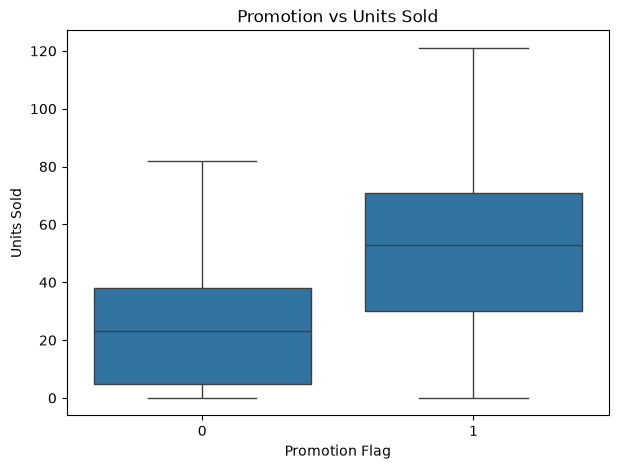

In [26]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Promotion_Flag',
    y='Units_Sold'
)

plt.title("Promotion vs Units Sold")
plt.xlabel("Promotion Flag")
plt.ylabel("Units Sold")
plt.show()

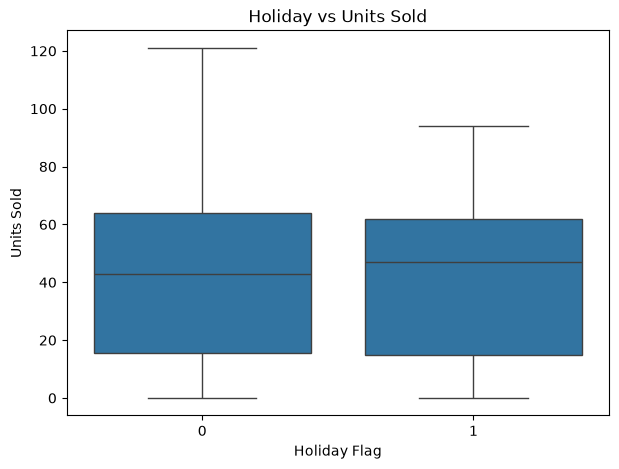

In [27]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Holiday_Flag',
    y='Units_Sold'
)

plt.title("Holiday vs Units Sold")
plt.xlabel("Holiday Flag")
plt.ylabel("Units Sold")
plt.show()

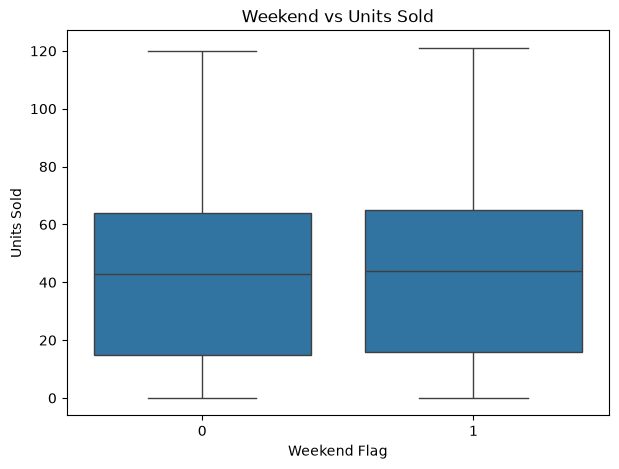

In [28]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Is_Weekend',
    y='Units_Sold'
)

plt.title("Weekend vs Units Sold")
plt.xlabel("Weekend Flag")
plt.ylabel("Units Sold")
plt.show()

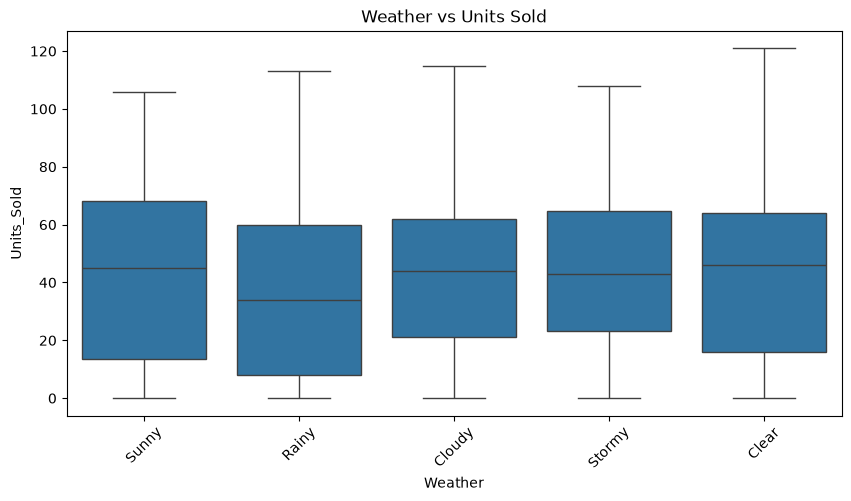

In [29]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='Weather',
    y='Units_Sold'
)

plt.title("Weather vs Units Sold")
plt.xticks(rotation=45)
plt.show()

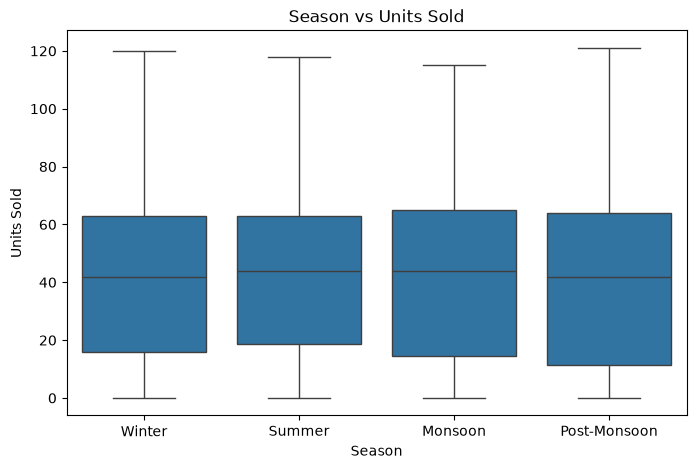

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Season',
    y='Units_Sold'
)

plt.title("Season vs Units Sold")
plt.xlabel("Season")
plt.ylabel("Units Sold")
plt.show()

Time Series EDA

In [31]:
df = df.sort_values('Date')

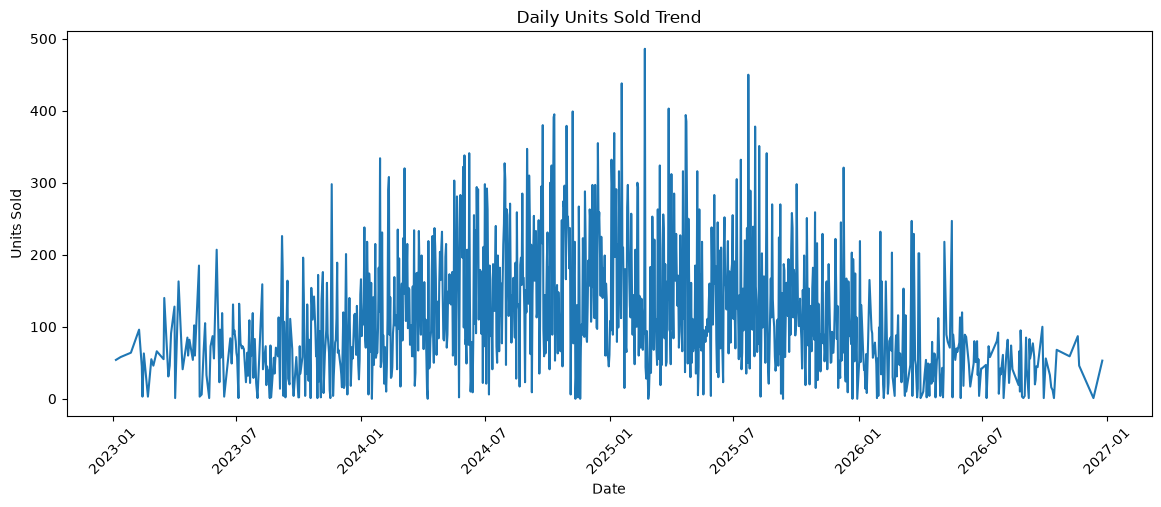

In [32]:
daily_sales = df.groupby('Date')['Units_Sold'].sum()

plt.figure(figsize=(14,5))

plt.plot(daily_sales)

plt.title("Daily Units Sold Trend")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

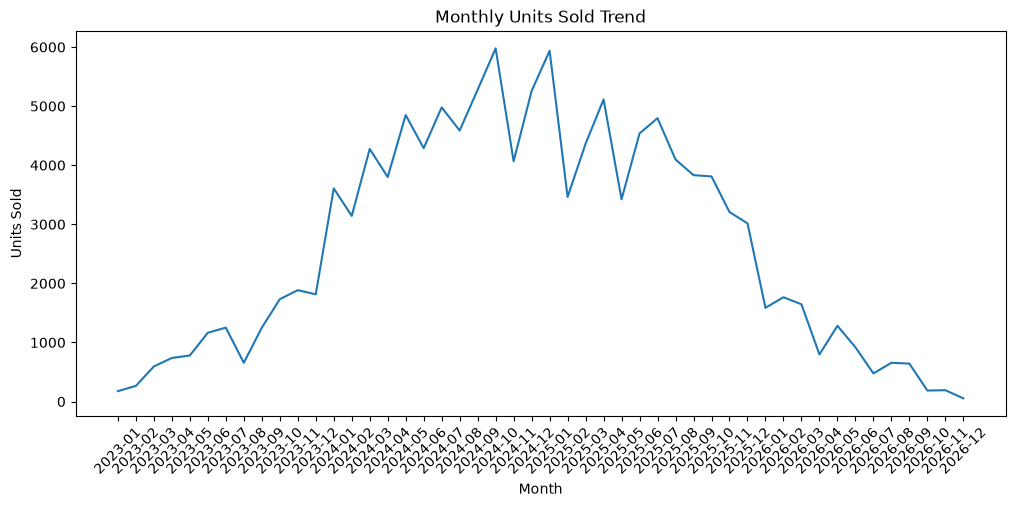

In [33]:
monthly_sales = df.groupby(
    df['Date'].dt.to_period('M')
)['Units_Sold'].sum()

plt.figure(figsize=(12,5))

plt.plot(monthly_sales.index.astype(str), monthly_sales.values)

plt.title("Monthly Units Sold Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

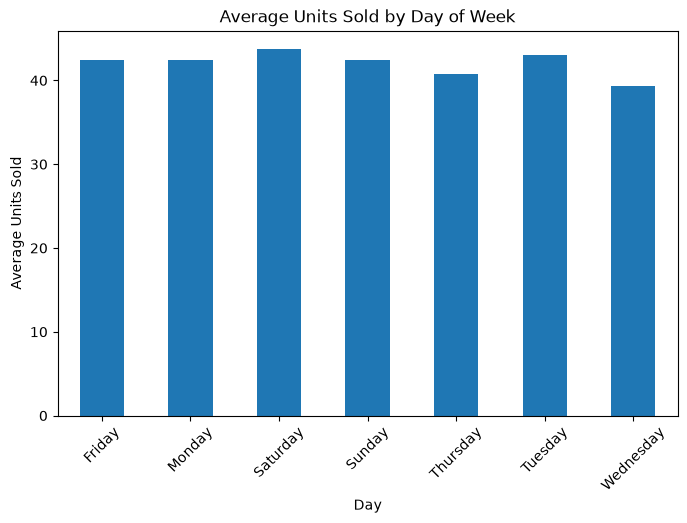

In [34]:
day_sales = df.groupby(
    'Day_of_Week'
)['Units_Sold'].mean()

day_sales.plot(kind='bar', figsize=(8,5))

plt.title("Average Units Sold by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)
plt.show()

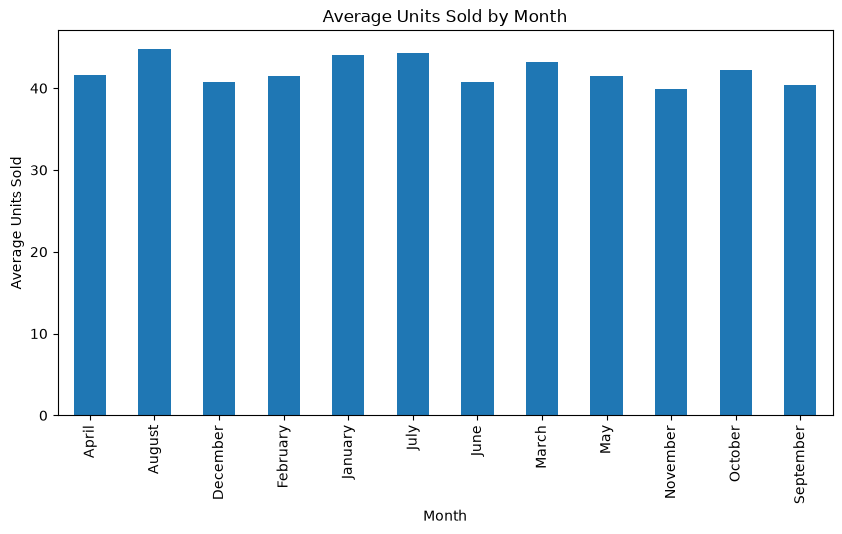

In [35]:
month_sales = df.groupby(
    'Month'
)['Units_Sold'].mean()

month_sales.plot(kind='bar', figsize=(10,5))

plt.title("Average Units Sold by Month")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")
plt.show()

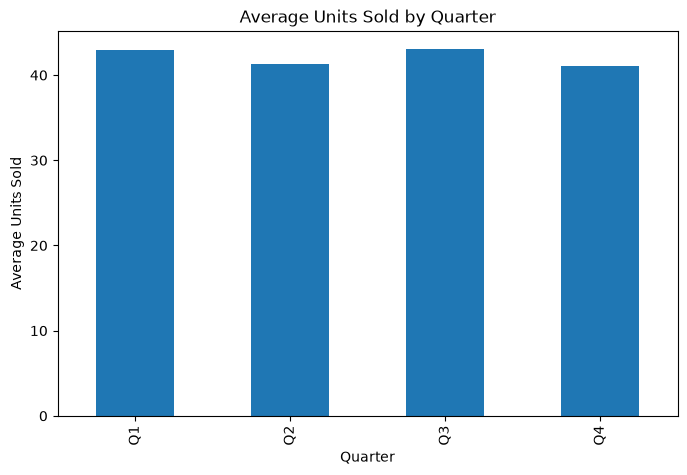

In [36]:
quarter_sales = df.groupby(
    'Quarter'
)['Units_Sold'].mean()

quarter_sales.plot(kind='bar', figsize=(8,5))

plt.title("Average Units Sold by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Average Units Sold")
plt.show()

Corelation Analysis

In [37]:
numeric_df = df.select_dtypes(include=np.number)

correlation_with_target = numeric_df.corr()['Units_Sold'].sort_values(
    ascending=False
)

print(correlation_with_target)

Units_Sold             1.000000
Stock_Availability     0.693741
Revenue                0.568104
Discount_Percentage    0.416296
Promotion_Flag         0.383766
Marketing_Spend        0.269368
Local_Event_Flag       0.153969
Is_Weekend             0.023689
Holiday_Flag          -0.000033
Week_of_Year          -0.020770
Is_Weekday            -0.023689
Economic_Indicator    -0.027352
Row_ID                -0.054543
Price                 -0.306506
Competitor_Price      -0.309005
Name: Units_Sold, dtype: float64


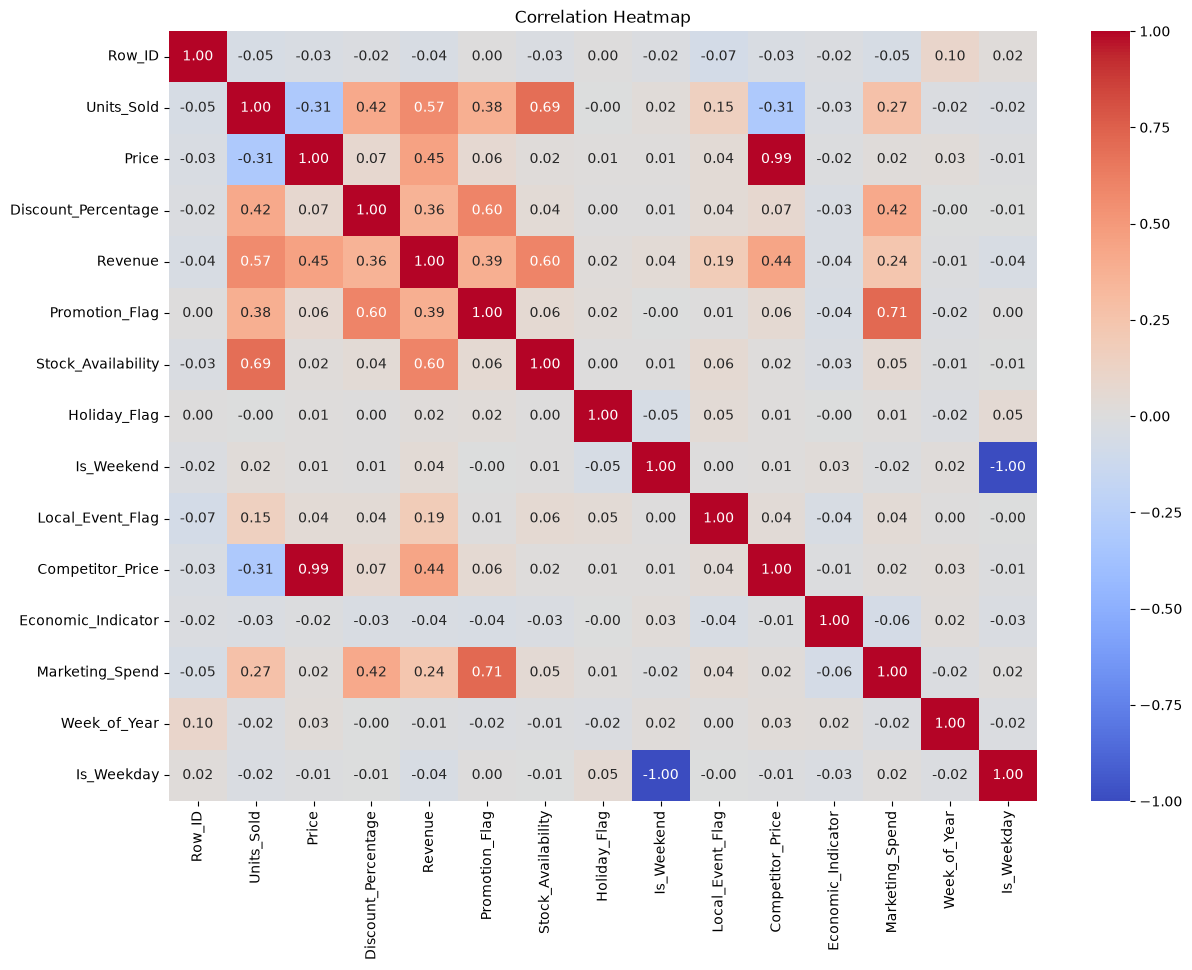

In [38]:
plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

Outliers Analysis

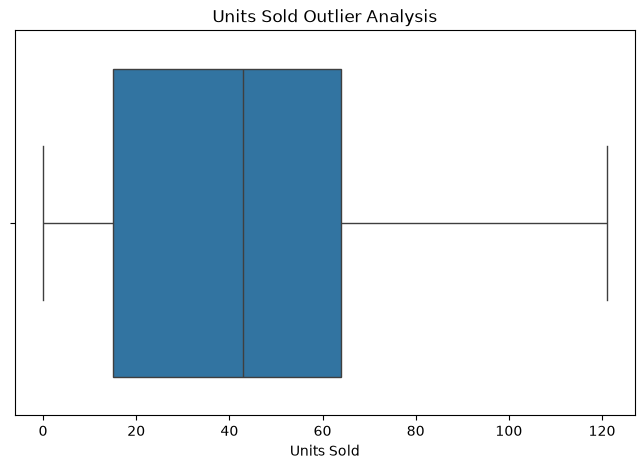

In [39]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Units_Sold'])

plt.title("Units Sold Outlier Analysis")
plt.xlabel("Units Sold")
plt.show()

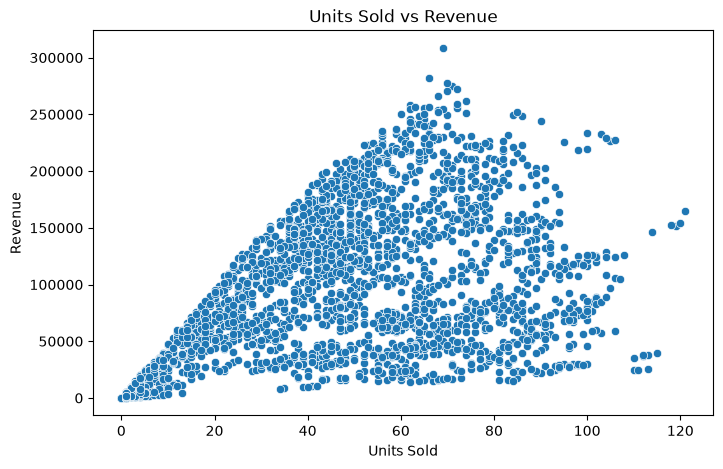

In [40]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Units_Sold',
    y='Revenue'
)

plt.title("Units Sold vs Revenue")
plt.xlabel("Units Sold")
plt.ylabel("Revenue")
plt.show()

# FEATURE ENGINEERING

Date Features

Year,
Month,
Day,
Day_of_Week,
Week_of_Year,
Day_of_Year,
Is_Weekend,
Is_Month_Start,
Is_Month_End

These help the model understand seasonality and time patterns.

In [41]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Day_of_Week'] = df['Date'].dt.dayofweek
df['Week_of_Year'] = df['Date'].dt.isocalendar().week.astype(int)
df['Day_of_Year'] = df['Date'].dt.dayofyear

df['Is_Weekend'] = (df['Day_of_Week'] >= 5).astype(int)
df['Is_Month_Start'] = df['Date'].dt.is_month_start.astype(int)
df['Is_Month_End'] = df['Date'].dt.is_month_end.astype(int)

Lag Features

Lag features use previous sales values of the same product to help predict current Units_Sold.
Lag_1, Lag_7, and Lag_14 capture yesterday's, previous week's, and two-weeks-ago sales patterns.

In [42]:
df = df.sort_values(['Product_ID', 'Date']).reset_index(drop=True)

df['Units_Sold_Lag_1'] = (df.groupby('Product_ID')['Units_Sold'].shift(1))

df['Units_Sold_Lag_7'] = (df.groupby('Product_ID')['Units_Sold'].shift(7))

df['Units_Sold_Lag_14'] = (df.groupby('Product_ID')['Units_Sold'].shift(14))

Rolling Sales Features

Rolling mean calculates the average historical Units_Sold over the previous 7 and 14 observations.


In [43]:
df['Rolling_Mean_7'] = (
    df.groupby('Product_ID')['Units_Sold']
      .transform(lambda x: x.shift(1).rolling(7).mean())
)

df['Rolling_Mean_14'] = (
    df.groupby('Product_ID')['Units_Sold']
      .transform(lambda x: x.shift(1).rolling(14).mean())
)

Rolling Maximum / Minimum

These features capture the recent maximum, minimum, and variation in product sales.
They help the model understand not only average demand but also recent sales range and volatility.

In [44]:
# 7-day rolling maximum
df['Rolling_7_Max'] = (
    df.groupby('Product_ID')['Units_Sold']
      .transform(lambda x: x.shift(1).rolling(7).max())
)

# 7-day rolling minimum
df['Rolling_7_Min'] = (
    df.groupby('Product_ID')['Units_Sold']
      .transform(lambda x: x.shift(1).rolling(7).min())
)

# 7-day rolling standard deviation
df['Rolling_7_Std'] = (
    df.groupby('Product_ID')['Units_Sold']
      .transform(lambda x: x.shift(1).rolling(7).std())
)

Price-Based Features

Price_Difference shows whether our product is more or less expensive than the competitor.
Price_Ratio represents our price relative to the competitor's price and can help explain demand changes.

It helps us to identify whether our product is More expensive than competitor, Cheaper than competitor, or Similarly priced

In [45]:
# Difference between our price and competitor price
df['Price_Difference'] = (
    df['Price'] - df['Competitor_Price']
)

# Ratio between our price and competitor price
df['Price_Ratio'] = (
    df['Price'] / (df['Competitor_Price'] + 1e-6)
)

Discount Feature

Discount_Amount converts the discount percentage into an actual discount value.
This gives the model another way to understand how discounting may affect Units_Sold.

In [46]:
# Calculate actual discount amount
df['Discount_Amount'] = (
    df['Price'] *
    df['Discount_Percentage'] / 100
)

Holiday Features

This feature identifies dates where a holiday and weekend occur together.
Such periods may have different customer demand patterns compared with normal weekdays.

In [47]:
# Holiday and weekend interaction
df['Holiday_Weekend'] = (
    df['Holiday_Flag'] *
    df['Is_Weekend']
)

Seasonal / Cyclical Features

Cyclical encoding represents time variables so that the beginning and end of a cycle remain mathematically close.
This helps the model understand repeating patterns such as December → January and Sunday → Monday.

It helps forecasting models understand repeating patterns

In [48]:
import numpy as np

# Cyclical encoding for month
df['Month_Sin'] = np.sin(
    2 * np.pi * df['Month'] / 12
)

df['Month_Cos'] = np.cos(
    2 * np.pi * df['Month'] / 12
)

# Cyclical encoding for day of week
df['Day_Sin'] = np.sin(
    2 * np.pi * df['Day_of_Week'] / 7
)

df['Day_Cos'] = np.cos(
    2 * np.pi * df['Day_of_Week'] / 7
)

Product-Level Features

This feature represents the historical average sales of each product up to the previous observation.
It helps the model understand that different products can naturally have different sales levels.

In [49]:
# Calculate historical average Units_Sold for each product
df['Product_Avg_Units_Sold'] = (
    df.groupby('Product_ID')['Units_Sold']
      .transform(
          lambda x: x.shift(1).expanding().mean()
      )
)

Store-Level Features

This feature captures the historical sales level of each store using only previous observations.
It helps the model learn that some stores may naturally generate higher or lower sales.

In [50]:
# Historical average Units_Sold for each store
df['Store_Avg_Units_Sold'] = (
    df.groupby('Store_ID')['Units_Sold']
      .transform(
          lambda x: x.shift(1).expanding().mean()
      )
)

Categorical Encoding

One-hot encoding converts categorical values into numerical columns that machine-learning models can understand.

In [51]:
categorical_cols = [
    'Product_ID',
    'Product_Name',
    'Category',
    'Store_ID',
    'Store_Location',
    'Holiday_Name',
    'Season',
    'Weather',
    'Sales_Channel',
    'Customer_Segment'
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    dtype=int
)

In [52]:
# Convert Quarter from Q1, Q2, Q3, Q4 to numeric values
df['Quarter'] = (
    df['Quarter']
    .astype(str)
    .str.replace('Q', '', regex=False)
    .astype(int)
)

print(df['Quarter'].dtype)
print(df['Quarter'].unique())

int64
[1 2 3 4]


Remove Unnecessary Features

Row_ID does not provide useful predictive information, while Date has already been converted into useful time features.
Revenue is removed because it can directly depend on Units_Sold, which can cause target leakage.

In [53]:
# Remove ID and leakage-prone columns
columns_to_remove = [
    'Row_ID',
    'Revenue'
]

df = df.drop(
    columns=columns_to_remove,
    errors='ignore'
)

Handle Missing Values Created by Lag/Rolling Features

Lag and rolling features naturally produce missing values because previous observations are unavailable at the beginning of each product's history.
First we check the missing values so that we only remove rows caused by insufficient historical information.

In [54]:
# Check missing values
missing_values = df.isnull().sum()

print(
    missing_values[
        missing_values > 0
    ].sort_values(ascending=False)
)

Rolling_Mean_14           112
Units_Sold_Lag_14         112
Rolling_7_Min              56
Units_Sold_Lag_7           56
Rolling_Mean_7             56
Rolling_7_Max              56
Rolling_7_Std              56
Units_Sold_Lag_1            8
Product_Avg_Units_Sold      8
Store_Avg_Units_Sold        4
dtype: int64


Remove rows with insufficient history

We remove only the initial rows where the required historical sales information is unavailable.
We use the 14-day history as our maximum window, so this preserves significantly more data than using 30-day lag and rolling features.

In [55]:
lag_rolling_cols = [
    'Units_Sold_Lag_1',
    'Units_Sold_Lag_7',
    'Units_Sold_Lag_14',
    'Rolling_Mean_7',
    'Rolling_Mean_14',
    'Rolling_7_Max',
    'Rolling_7_Min',
    'Rolling_7_Std'
]

df = df.dropna(
    subset=lag_rolling_cols
).reset_index(drop=True)

Final Missing Value Check

This verifies whether any missing values remain after feature engineering and cleaning.
The final shape tells us how many rows and features are available for model training.

In [56]:
print("Remaining missing values:")
print(df.isnull().sum().sum())

print("Final dataset shape:")
print(df.shape)

Remaining missing values:
0
Final dataset shape:
(2888, 93)


Feature & Target Separation

In [57]:
# Target
y = df['Units_Sold']

# Features
X = df.drop(columns=['Units_Sold'])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2888, 92)
y shape: (2888,)


# MODELS

# 1. XGBoost

XGBoost Model Training

XGBoost learns the relationship between your engineered features and Units_Sold.
It is useful for this project because it can learn nonlinear effects from price, promotion, historical sales, and other business features.

XGBoost Prediction

After training, the model predicts Units_Sold for the future observations in the test dataset.
These predictions will later be compared with the actual sales values.

XGBoost Evaluation

MAE shows the average prediction error, while RMSE gives more importance to larger errors.
R² indicates how much of the variation in Units_Sold is explained by the model.

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
from xgboost import XGBRegressor
 
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
 

In [110]:
n = len(X)
 
train_end = int(n * 0.70)
val_end = int(n * 0.85)
 
X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]
 
X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]
 
X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

In [111]:
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)
 
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

X_train: (2021, 92)
X_val  : (433, 92)
X_test : (434, 92)
y_train: (2021,)
y_val  : (433,)
y_test : (434,)


In [112]:
from xgboost import XGBRegressor
 
xgb_model = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=7,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.01,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42
)

In [115]:
xgb_model.fit(
    X_train,
    y_train
)
 
print("XGBoost Training Completed!")
 

XGBoost Training Completed!


In [116]:
from sklearn.model_selection import train_test_split
 
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)
 
xgb_model.fit(X_train, y_train)
y_val_pred = xgb_model.predict(X_val)

In [117]:
y_pred_xgb= xgb_model.predict(X_test)

In [140]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
 
xgb_mae = mean_absolute_error(
    y_val,
    y_val_pred
)
 
xgb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred
    )
)
 
xgb_r2 = r2_score(
    y_val,
    y_val_pred
)
 
print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"R²   : {xgb_r2:.4f}")
print(f"R² % : {xgb_r2 * 100:.2f}%")
 

MAE  : 4.34
RMSE : 5.99
R²   : 0.9570
R² % : 95.70%


XGBoost Feature Importance

Feature importance is examined to understand which engineered variables contribute most to the prediction of Units_Sold.

# 2. LSTM

Install Required Libraries

TensorFlow is needed for LSTM, and statsmodels/pmdarima/prophet are needed for the ARIMA and Prophet sections further below. Uncomment the pip install line the first time you run this in a fresh environment.

In [63]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)

Prepare Data for LSTM

LSTM needs input reshaped into 3D sequences `(samples, timesteps, features)`. We reuse the same engineered feature set built for XGBoost (lag, rolling, price, holiday, cyclical features), scale it with MinMaxScaler (LSTM trains much better on scaled inputs), and build sliding windows of `LOOKBACK` past rows to predict the next `Units_Sold` value. This keeps the comparison with XGBoost fair since both use the same feature set.

In [64]:
# Sort chronologically (same engineered dataframe used for XGBoost)
lstm_df = df.sort_values("Date").reset_index(drop=True)

feature_cols = [c for c in lstm_df.columns if c not in ["Units_Sold", "Date"]]

X_lstm_raw = lstm_df[feature_cols].values
y_lstm_raw = lstm_df["Units_Sold"].values.reshape(-1, 1)

# Scale features and target separately so we can inverse-transform predictions later
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(X_lstm_raw)
y_scaled = target_scaler.fit_transform(y_lstm_raw)

LOOKBACK = 14  # matches the 14-day lag/rolling window already used in feature engineering

def create_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, LOOKBACK)

print("Sequence shape:", X_seq.shape)   # (samples, timesteps, features)
print("Target shape  :", y_seq.shape)

Sequence shape: (2874, 14, 91)
Target shape  : (2874, 1)


Train / Validation / Test Split (chronological)

In [65]:
train_size = int(len(X_seq) * 0.70)
val_size = int(len(X_seq) * 0.15)

X_train_lstm = X_seq[:train_size]
y_train_lstm = y_seq[:train_size]

X_val_lstm = X_seq[train_size:train_size + val_size]
y_val_lstm = y_seq[train_size:train_size + val_size]

X_test_lstm = X_seq[train_size + val_size:]
y_test_lstm = y_seq[train_size + val_size:]

print("Train:", X_train_lstm.shape)
print("Val  :", X_val_lstm.shape)
print("Test :", X_test_lstm.shape)

Train: (2011, 14, 91)
Val  : (431, 14, 91)
Test : (432, 14, 91)


LSTM Architecture Search

Similar in spirit to the RandomizedSearchCV used for XGBoost, a small grid of architectures is tried and the one with the lowest validation loss is kept, instead of guessing a single configuration.

In [66]:
def build_lstm(units=64, dropout=0.2, lookback=LOOKBACK, n_features=X_train_lstm.shape[2]):
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(lookback, n_features)),
        Dropout(dropout),
        LSTM(units // 2),
        Dropout(dropout),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

param_grid_lstm = [
    {"units": 32, "dropout": 0.1},
    {"units": 64, "dropout": 0.2},
    {"units": 128, "dropout": 0.3},
]

best_val_loss = np.inf
best_config = None

for cfg in param_grid_lstm:
    model = build_lstm(**cfg)
    es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    history = model.fit(
        X_train_lstm, y_train_lstm,
        validation_data=(X_val_lstm, y_val_lstm),
        epochs=60,
        batch_size=32,
        callbacks=[es],
        verbose=0
    )
    val_loss = min(history.history["val_loss"])
    print(cfg, "-> val_loss:", val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_config = cfg

print("\nBest LSTM Config:", best_config)

c:\Users\Nishanth\anaconda3\envs\sales_lstm\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


{'units': 32, 'dropout': 0.1} -> val_loss: 0.057139553129673004
{'units': 64, 'dropout': 0.2} -> val_loss: 0.05769634619355202
{'units': 128, 'dropout': 0.3} -> val_loss: 0.05743521824479103

Best LSTM Config: {'units': 32, 'dropout': 0.1}


Final LSTM Training

Epoch 1/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0651 - val_loss: 0.0588 - learning_rate: 0.0010
Epoch 2/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0612 - val_loss: 0.0590 - learning_rate: 0.0010
Epoch 3/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0603 - val_loss: 0.0584 - learning_rate: 0.0010
Epoch 4/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0605 - val_loss: 0.0574 - learning_rate: 0.0010
Epoch 5/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0600 - val_loss: 0.0583 - learning_rate: 0.0010
Epoch 6/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0605 - val_loss: 0.0582 - learning_rate: 0.0010
Epoch 7/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0601 - val_loss: 0.0576 - learning_rate: 0.0010
Epoch 8/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0594 - val_loss: 0.0587 - learning_rate: 0.0010
Epoch 9/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0604 - val_loss: 0.0582 - learning_rate: 0.0010
Epoch 10/150
63/63

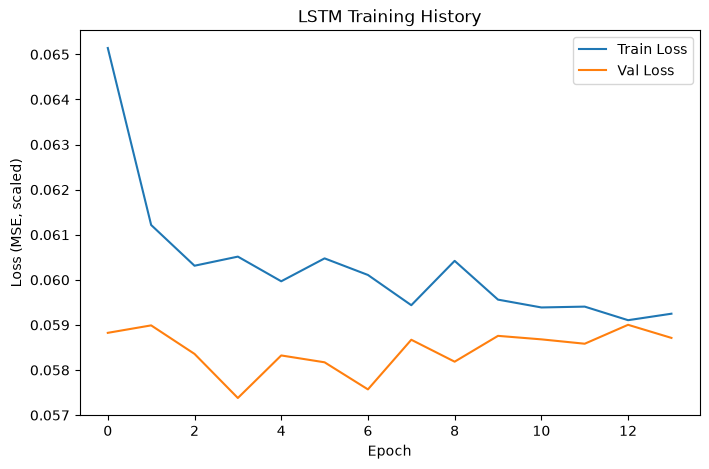

In [67]:
final_lstm = build_lstm(**best_config)

es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
rlrop = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)

history = final_lstm.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=150,
    batch_size=32,
    callbacks=[es, rlrop],
    verbose=1
)

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE, scaled)")
plt.legend()
plt.show()

LSTM Prediction & Evaluation

Predictions are made in the scaled space, so they are inverse-transformed back to real `Units_Sold` values before computing MAE, RMSE and R², so the numbers are on the same scale as the XGBoost results.

In [68]:
lstm_pred_scaled = final_lstm.predict(X_test_lstm)

lstm_pred = target_scaler.inverse_transform(lstm_pred_scaled)
y_test_lstm_actual = target_scaler.inverse_transform(y_test_lstm)

lstm_mae = mean_absolute_error(y_test_lstm_actual, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_lstm_actual, lstm_pred))
lstm_r2 = r2_score(y_test_lstm_actual, lstm_pred)

print("LSTM Results")
print("------------")
print("MAE :", lstm_mae)
print("RMSE:", lstm_rmse)
print("R²  :", lstm_r2)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
LSTM Results
------------
MAE : 24.084968822973746
RMSE: 28.15557640720206
R²  : -0.008161025999195104


# 3. ARIMA

ARIMA models a single time series from its own past values, so we aggregate `Units_Sold` across all products and stores into one daily total (the same aggregation already used in the Time Series EDA section). Because the raw data does not have a row for every calendar day, we reindex to a continuous daily frequency and interpolate the gaps before modeling — ARIMA and SARIMAX both require an evenly spaced series.

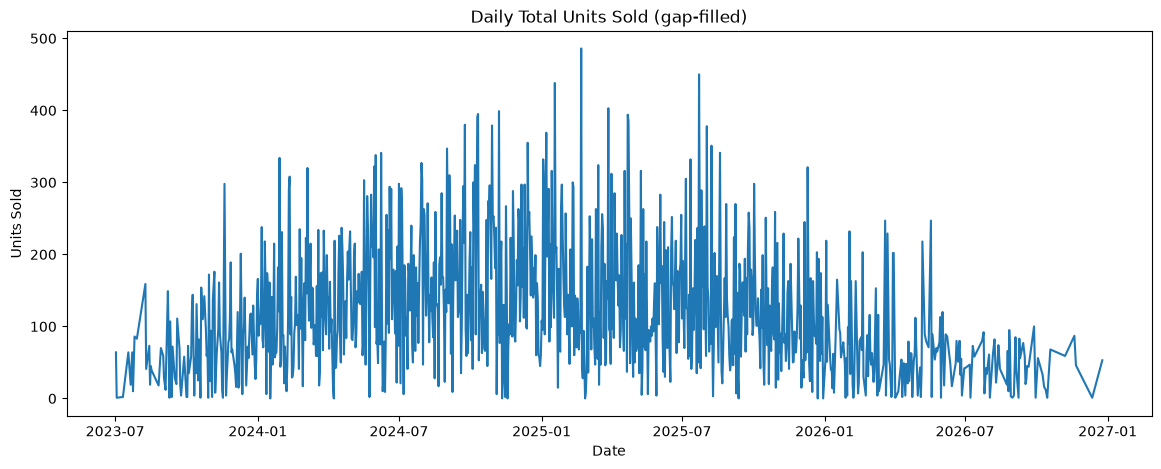

In [69]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import pmdarima as pm

# Aggregate to one total daily series
daily_total = df.groupby("Date")["Units_Sold"].sum()

# Reindex to a continuous daily calendar and fill gaps
full_range = pd.date_range(daily_total.index.min(), daily_total.index.max(), freq="D")
daily_total = daily_total.reindex(full_range)
daily_total = daily_total.interpolate(method="linear").bfill()
daily_total.index.name = "Date"

plt.figure(figsize=(14,5))
plt.plot(daily_total)
plt.title("Daily Total Units Sold (gap-filled)")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

Stationarity Check

In [70]:
adf_result = adfuller(daily_total)
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Series is", "stationary" if adf_result[1] < 0.05 else "non-stationary")

ADF Statistic: -2.652314051731408
p-value: 0.08265969844593174
Series is non-stationary


Train/Test Split (chronological, same 80/20 split style as XGBoost)

In [71]:
split_point = int(len(daily_total) * 0.80)
arima_train = daily_total.iloc[:split_point]
arima_test = daily_total.iloc[split_point:]

print("Train size:", len(arima_train))
print("Test size :", len(arima_test))

Train size: 1018
Test size : 255


Auto ARIMA Order Search

`auto_arima` searches over `(p,d,q)(P,D,Q,7)` combinations (weekly seasonality) and keeps the configuration with the lowest AIC — a more systematic search than hand-picking an order.

In [72]:
auto_model = pm.auto_arima(
    arima_train,
    seasonal=True,
    m=7,                     # weekly seasonality
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    max_P=2, max_Q=2,
    d=None, D=None,
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action="ignore"
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=12377.719, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=12373.729, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=12130.426, Time=0.11 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=11768.355, Time=0.37 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=12371.730, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=11766.372, Time=0.13 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=11768.356, Time=0.31 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=11770.245, Time=0.77 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=11765.151, Time=0.22 sec
 ARIMA(1,1,1)(1,0,0)[7] intercept   : AIC=11767.149, Time=0.47 sec
 ARIMA(1,1,1)(0,0,1)[7] intercept   : AIC=11767.149, Time=0.50 sec
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=11769.113, Time=0.88 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=12128.443, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[7] intercept   : AIC=11767.017, Time=0.28 sec
 ARIMA(1,1,2)(0,0,0

ARIMA Model Training & Forecasting

In [73]:
best_order = auto_model.order
best_seasonal_order = auto_model.seasonal_order

sarimax_model = SARIMAX(
    arima_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

arima_forecast = sarimax_model.get_forecast(steps=len(arima_test))
arima_pred = arima_forecast.predicted_mean

ARIMA Evaluation

ARIMA Results
-------------
Order: (0, 1, 2) Seasonal Order: (0, 0, 0, 7)
MAE : 25.467236014765206
RMSE: 34.55503437063025
R²  : -0.060458747522067036


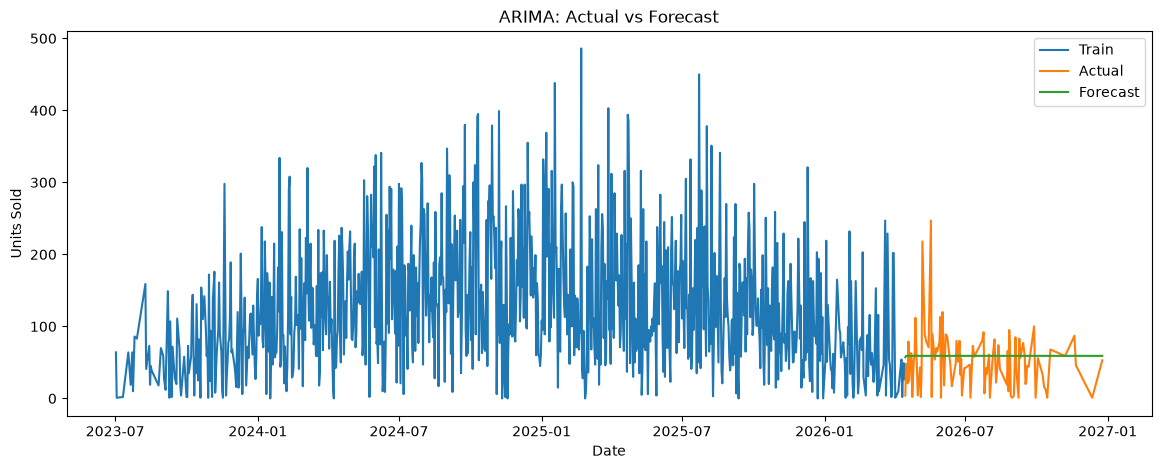

In [74]:
arima_mae = mean_absolute_error(arima_test, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(arima_test, arima_pred))
arima_r2 = r2_score(arima_test, arima_pred)

print("ARIMA Results")
print("-------------")
print("Order:", best_order, "Seasonal Order:", best_seasonal_order)
print("MAE :", arima_mae)
print("RMSE:", arima_rmse)
print("R²  :", arima_r2)

plt.figure(figsize=(14,5))
plt.plot(arima_train.index, arima_train, label="Train")
plt.plot(arima_test.index, arima_test, label="Actual")
plt.plot(arima_test.index, arima_pred, label="Forecast")
plt.title("ARIMA: Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.show()

# 4. Prophet

Prophet also models the aggregated daily series, but lets us add extra regressors — daily promotion rate, holiday flag, weekend flag and marketing spend — so it can use some of the same business signals XGBoost had access to, on top of its own trend/seasonality decomposition.

In [75]:
from prophet import Prophet

c:\Users\Nishanth\anaconda3\envs\sales_lstm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [76]:
daily_regressors = df.groupby("Date").agg(
    Promotion_Rate=("Promotion_Flag", "mean"),
    Holiday_Flag=("Holiday_Flag", "max"),
    Is_Weekend=("Is_Weekend", "max"),
    Marketing_Spend=("Marketing_Spend", "sum")
)

prophet_df = daily_total.to_frame("y").join(daily_regressors)
prophet_df = prophet_df.ffill().fillna(0)
prophet_df = prophet_df.reset_index().rename(columns={"Date": "ds"})

prophet_df.head()

,ds,y,Promotion_Rate,Holiday_Flag,Is_Weekend,Marketing_Spend
0,2023-07-02,64.000,1.0,0.0,1.0,5121.154747
1,2023-07-03,1.000,0.0,0.0,0.0,526.163346
2,2023-07-04,1.125,0.0,0.0,0.0,526.163346
3,2023-07-05,1.250,0.0,0.0,0.0,526.163346
4,2023-07-06,1.375,0.0,0.0,0.0,526.163346


Train/Test Split (chronological)

In [77]:
split_point_p = int(len(prophet_df) * 0.80)
prophet_train = prophet_df.iloc[:split_point_p]
prophet_test = prophet_df.iloc[split_point_p:]

print("Train size:", len(prophet_train))
print("Test size :", len(prophet_test))

Train size: 1018
Test size : 255


Hyperparameter Search

A small grid search over `changepoint_prior_scale` and `seasonality_prior_scale` is used to reduce forecast error, validated on a holdout slice taken from the end of the training period (not the test set).

In [78]:
regressor_cols = ["Promotion_Rate", "Holiday_Flag", "Is_Weekend", "Marketing_Spend"]

param_grid_prophet = [
    {"changepoint_prior_scale": cps, "seasonality_prior_scale": sps}
    for cps in [0.01, 0.05, 0.1, 0.5]
    for sps in [1.0, 5.0, 10.0]
]

val_cutoff = int(len(prophet_train) * 0.85)
p_train_inner = prophet_train.iloc[:val_cutoff]
p_val_inner = prophet_train.iloc[val_cutoff:]

best_rmse = np.inf
best_params = None

for params in param_grid_prophet:
    m = Prophet(
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_prior_scale=params["seasonality_prior_scale"],
        weekly_seasonality=True,
        yearly_seasonality=True,
        daily_seasonality=False
    )
    for reg in regressor_cols:
        m.add_regressor(reg)

    m.fit(p_train_inner)

    val_forecast = m.predict(p_val_inner.drop(columns=["y"]))
    rmse = np.sqrt(mean_squared_error(p_val_inner["y"], val_forecast["yhat"]))

    if rmse < best_rmse:
        best_rmse = rmse
        best_params = params

print("Best Prophet Params:", best_params, "| Val RMSE:", best_rmse)

15:27:31 - cmdstanpy - INFO - Chain [1] start processing
15:27:32 - cmdstanpy - INFO - Chain [1] done processing
15:27:33 - cmdstanpy - INFO - Chain [1] start processing
15:27:33 - cmdstanpy - INFO - Chain [1] done processing
15:27:33 - cmdstanpy - INFO - Chain [1] start processing
15:27:34 - cmdstanpy - INFO - Chain [1] done processing
15:27:34 - cmdstanpy - INFO - Chain [1] start processing
15:27:35 - cmdstanpy - INFO - Chain [1] done processing
15:27:35 - cmdstanpy - INFO - Chain [1] start processing
15:27:35 - cmdstanpy - INFO - Chain [1] done processing
15:27:36 - cmdstanpy - INFO - Chain [1] start processing
15:27:36 - cmdstanpy - INFO - Chain [1] done processing
15:27:36 - cmdstanpy - INFO - Chain [1] start processing
15:27:37 - cmdstanpy - INFO - Chain [1] done processing
15:27:37 - cmdstanpy - INFO - Chain [1] start processing
15:27:37 - cmdstanpy - INFO - Chain [1] done processing
15:27:38 - cmdstanpy - INFO - Chain [1] start processing
15:27:38 - cmdstanpy - INFO - Chain [1]

Best Prophet Params: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 1.0} | Val RMSE: 55.173985952483434


Final Prophet Model Training & Forecast

In [79]:
final_prophet = Prophet(
    changepoint_prior_scale=best_params["changepoint_prior_scale"],
    seasonality_prior_scale=best_params["seasonality_prior_scale"],
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False
)
for reg in regressor_cols:
    final_prophet.add_regressor(reg)

final_prophet.fit(prophet_train)

prophet_forecast = final_prophet.predict(prophet_test.drop(columns=["y"]))
prophet_pred = prophet_forecast["yhat"].values

15:27:41 - cmdstanpy - INFO - Chain [1] start processing
15:27:41 - cmdstanpy - INFO - Chain [1] done processing


Prophet Evaluation

Prophet Results
---------------
MAE : 29.44897894374832
RMSE: 37.73842078356016
R²  : -0.2648486612312464


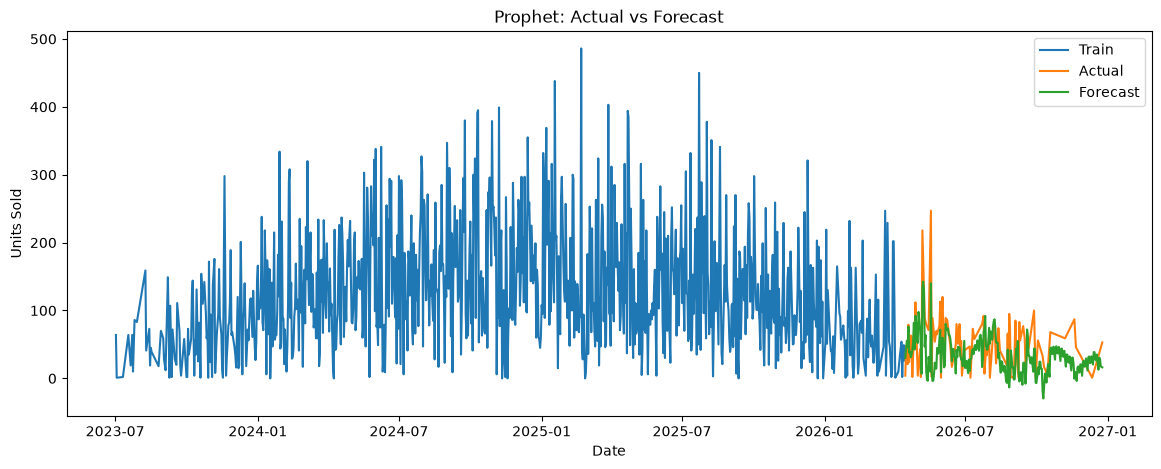

In [80]:
prophet_mae = mean_absolute_error(prophet_test["y"], prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(prophet_test["y"], prophet_pred))
prophet_r2 = r2_score(prophet_test["y"], prophet_pred)

print("Prophet Results")
print("---------------")
print("MAE :", prophet_mae)
print("RMSE:", prophet_rmse)
print("R²  :", prophet_r2)

plt.figure(figsize=(14,5))
plt.plot(prophet_train["ds"], prophet_train["y"], label="Train")
plt.plot(prophet_test["ds"], prophet_test["y"], label="Actual")
plt.plot(prophet_test["ds"], prophet_pred, label="Forecast")
plt.title("Prophet: Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.show()

# 5. Model Comparison

**Important caveat:** XGBoost and LSTM were evaluated on individual product/store-level rows, while ARIMA and Prophet forecast the aggregated daily total across all products and stores combined. They are solving different granularities of the same problem, so MAE/RMSE are not directly comparable in absolute terms across the two groups — R² gives a fairer relative sense of how much variance each model explains within its own target scale.

     Model        MAE       RMSE        R2
0  XGBoost   4.342758   5.992562  0.956991
1     LSTM  24.084969  28.155576 -0.008161
2    ARIMA  25.467236  34.555034 -0.060459
3  Prophet  29.448979  37.738421 -0.264849


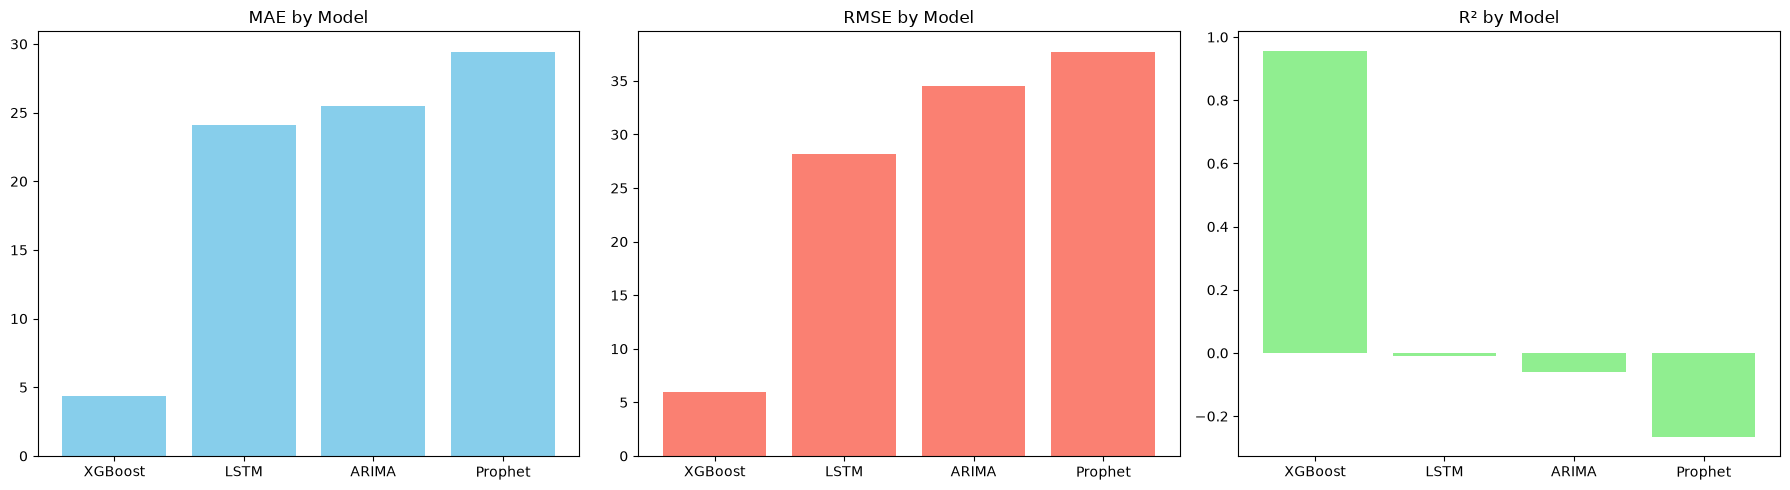

In [119]:
results = pd.DataFrame({
    "Model": ["XGBoost", "LSTM", "ARIMA", "Prophet"],
    "MAE": [xgb_mae, lstm_mae, arima_mae, prophet_mae],
    "RMSE": [xgb_rmse, lstm_rmse, arima_rmse, prophet_rmse],
    "R2": [xgb_r2, lstm_r2, arima_r2, prophet_r2]
})

print(results)

fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].bar(results["Model"], results["MAE"], color="skyblue")
axes[0].set_title("MAE by Model")

axes[1].bar(results["Model"], results["RMSE"], color="salmon")
axes[1].set_title("RMSE by Model")

axes[2].bar(results["Model"], results["R2"], color="lightgreen")
axes[2].set_title("R\u00b2 by Model")

plt.tight_layout()
plt.show()

# 6. LightGBM

LightGBM uses the exact same chronological train/test split and feature set already built for XGBoost (`X_train_tuned`, `X_test_tuned`, `y_train_tuned`, `y_test_tuned`), so results are directly comparable row-for-row — no re-aggregation like ARIMA/Prophet needed.

In [121]:
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [122]:
X = df.drop(columns=["Units_Sold"])
y = df["Units_Sold"]
 
split = int(len(df) * 0.80)
 
X_train = X.iloc[:split]
X_test = X.iloc[split:]
 
y_train = y.iloc[:split]
y_test = y.iloc[split:]
 
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2310, 92)
X_test: (578, 92)
y_train: (2310,)
y_test: (578,)


In [123]:
X = df.drop(columns=["Units_Sold"])
y = df["Units_Sold"]
 
split = int(len(df) * 0.80)
 
X_train = X.iloc[:split]
X_test = X.iloc[split:]
 
y_train = y.iloc[:split]
y_test = y.iloc[split:]
 
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2310, 92)
X_test: (578, 92)
y_train: (2310,)
y_test: (578,)


In [124]:
X_train = X_train.select_dtypes(include=np.number)
X_test = X_test.select_dtypes(include=np.number)

In [125]:
lgb_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

In [126]:
lgb_model.fit(
    X_train,
    y_train
)
 
print("LightGBM Training Completed!")
 
y_pred_lgb = lgb_model.predict(
    X_test
)
 
print("Prediction Completed!")
 

LightGBM Training Completed!
Prediction Completed!


In [127]:
lgbm_mae = mean_absolute_error(
    y_test,
    y_pred_lgb
)
 
lgbm_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lgb
    )
)
 
lgbm_r2 = r2_score(
    y_test,
    y_pred_lgb
)

In [129]:
print(f"MAE  : {lgbm_mae:.2f}")
print(f"RMSE : {lgbm_rmse:.2f}")
print(f"R²   : {lgbm_r2:.4f}")
print(f"R² % : {lgbm_r2 * 100:.2f}%")

MAE  : 5.89
RMSE : 7.76
R²   : 0.9260
R² % : 92.60%


# 7. CatBoost

CatBoost also uses the same `X_train_tuned` / `X_test_tuned` split. Note that the categorical columns were already one-hot encoded during feature engineering, so CatBoost is trained here as a plain numeric booster — it isn't using its native categorical handling, which would need the raw (non-dummy) category columns passed via `cat_features` instead.

In [130]:
import numpy as np
import matplotlib.pyplot as plt
 
from catboost import CatBoostRegressor
 
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [131]:
X = df.drop(columns=["Units_Sold"])
y = df["Units_Sold"]

In [132]:
split = int(len(df) * 0.80)
 
X_train = X.iloc[:split]
X_test = X.iloc[split:]
 
y_train = y.iloc[:split]
y_test = y.iloc[split:]
 
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2310, 92)
X_test : (578, 92)
y_train: (2310,)
y_test : (578,)


In [133]:
X_train = X_train.select_dtypes(
    include=np.number
)
 
X_test = X_test.select_dtypes(
    include=np.number
)
 
print("Features used:", X_train.columns.tolist())

Features used: ['Price', 'Discount_Percentage', 'Promotion_Flag', 'Stock_Availability', 'Day_of_Week', 'Month', 'Quarter', 'Holiday_Flag', 'Is_Weekend', 'Local_Event_Flag', 'Competitor_Price', 'Economic_Indicator', 'Marketing_Spend', 'Week_of_Year', 'Is_Weekday', 'Year', 'Day', 'Day_of_Year', 'Is_Month_Start', 'Is_Month_End', 'Units_Sold_Lag_1', 'Units_Sold_Lag_7', 'Units_Sold_Lag_14', 'Rolling_Mean_7', 'Rolling_Mean_14', 'Rolling_7_Max', 'Rolling_7_Min', 'Rolling_7_Std', 'Price_Difference', 'Price_Ratio', 'Discount_Amount', 'Holiday_Weekend', 'Month_Sin', 'Month_Cos', 'Day_Sin', 'Day_Cos', 'Product_Avg_Units_Sold', 'Store_Avg_Units_Sold', 'Product_ID_P001', 'Product_ID_P002', 'Product_ID_P003', 'Product_ID_P004', 'Product_ID_P005', 'Product_ID_P006', 'Product_ID_P007', 'Product_ID_P008', 'Product_Name_Bluetooth Speaker', 'Product_Name_Coffee Maker', 'Product_Name_LED Desk Lamp', 'Product_Name_Notebook Pack', 'Product_Name_Office Chair', 'Product_Name_Running Shoes', 'Product_Name_Wire

In [134]:
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

In [135]:
cat_model.fit(
    X_train,
    y_train
)
 
print("CatBoost Training Completed!")

CatBoost Training Completed!


In [136]:
y_pred_cat= cat_model.predict(
    X_test
)
 
print("CatBoost Prediction Completed!")

CatBoost Prediction Completed!


In [137]:
cat_mae = mean_absolute_error(
    y_test,
    y_pred_cat
)
 
cat_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_cat
    )
)
 
cat_r2 = r2_score(
    y_test,
    y_pred_cat
)

In [138]:
print(f"MAE  : {cat_mae:.2f}")
print(f"RMSE : {cat_rmse:.2f}")
print(f"R²   : {cat_r2:.4f}")
print(f"R² % : {cat_r2 * 100:.2f}%")

MAE  : 5.85
RMSE : 7.60
R²   : 0.9290
R² % : 92.90%


# 8. XGBoost vs LightGBM vs CatBoost Comparison

Unlike the ARIMA/Prophet comparison earlier, this one is apples-to-apples: XGBoost, LightGBM and CatBoost all trained on the identical chronological 80/20 split (`X_train_tuned` / `X_test_tuned`) with the identical 92-feature table, so MAE and RMSE here are directly comparable in the same `Units_Sold` units.

      Model       MAE      RMSE        R2
0   XGBoost  4.342758  5.992562  0.956991
1  LightGBM  5.885212  7.755756  0.925998
2  CatBoost  5.850573  7.598729  0.928964


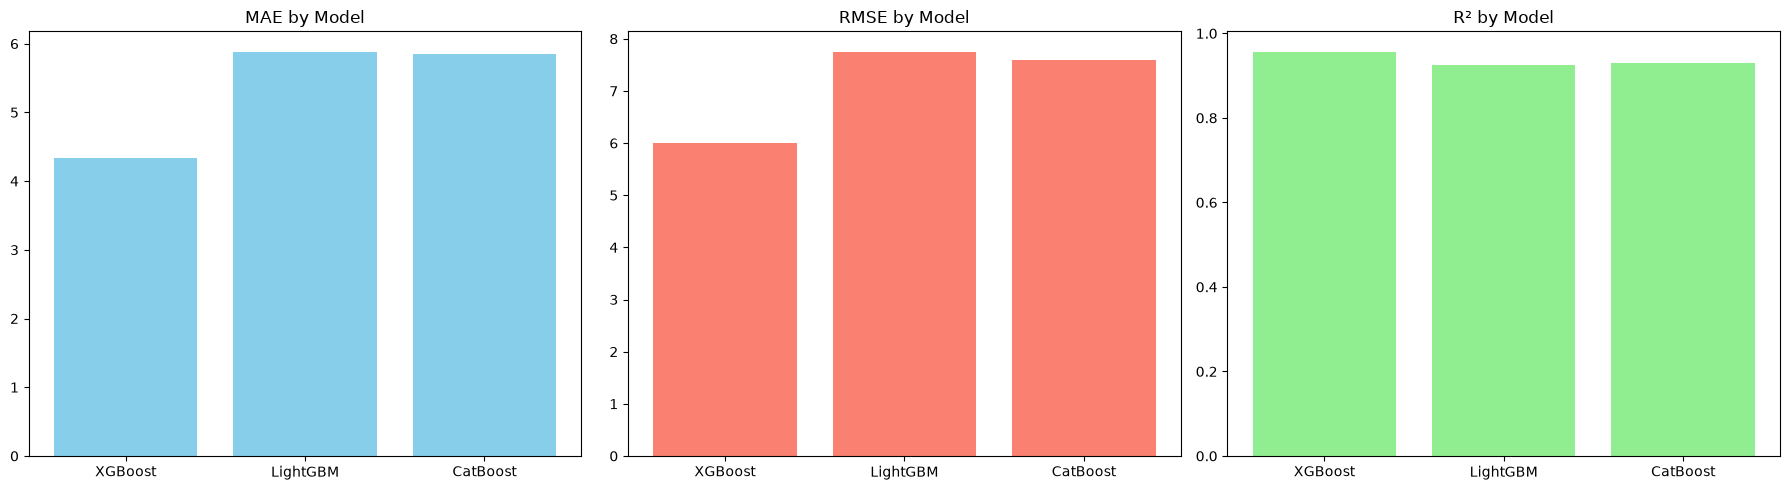

In [139]:
tree_results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM", "CatBoost"],
    "MAE": [xgb_mae, lgbm_mae, cat_mae],
    "RMSE": [xgb_rmse, lgbm_rmse, cat_rmse],
    "R2": [xgb_r2, lgbm_r2, cat_r2]
})

print(tree_results)

fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].bar(tree_results["Model"], tree_results["MAE"], color="skyblue")
axes[0].set_title("MAE by Model")

axes[1].bar(tree_results["Model"], tree_results["RMSE"], color="salmon")
axes[1].set_title("RMSE by Model")

axes[2].bar(tree_results["Model"], tree_results["R2"], color="lightgreen")
axes[2].set_title("R\u00b2 by Model")

plt.tight_layout()
plt.show()

Actual vs Predicted: All Three Models

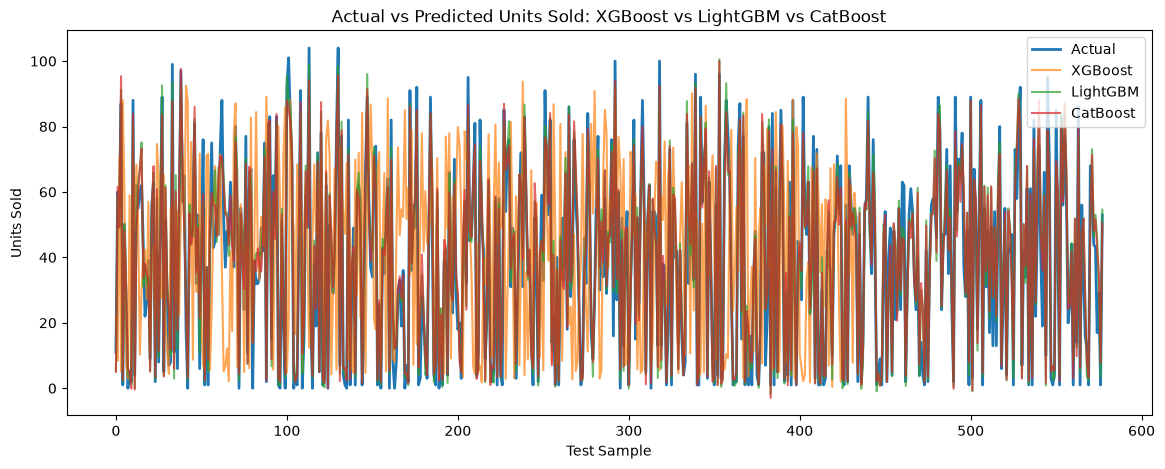

In [143]:
plt.figure(figsize=(14,5))

plt.plot(y_test.values, label="Actual", linewidth=2)
plt.plot(y_pred_xgb, label="XGBoost", alpha=0.7)
plt.plot(y_pred_lgb, label="LightGBM", alpha=0.7)
plt.plot(y_pred_cat, label="CatBoost", alpha=0.7)

plt.title("Actual vs Predicted Units Sold: XGBoost vs LightGBM vs CatBoost")
plt.xlabel("Test Sample")
plt.ylabel("Units Sold")
plt.legend()
plt.show()

# XGBoost Selected — Deployment Workflow

XGBoost had the best MAE/RMSE/R² among all six models on the row-level test set, so it's the one taken forward from here: error analysis → walk-forward validation → final retraining → future prediction → saving → deployment. All cells below reuse `best_xgb`, `X_train_tuned`, `X_test_tuned`, `y_train_tuned`, `y_test_tuned`, `xgb_tuned_pred`, `X_xgb_tuned`, `y_xgb_tuned`, and `random_search.best_params_` that were already created in the XGBoost section.

# 9. Error Analysis

Before trusting XGBoost for deployment, it's worth understanding *where* it's wrong, not just *how much* it's wrong on average. This section looks at the residual distribution, whether errors grow with predicted volume, whether errors drift over time, and which products/categories/stores are hardest to predict.

In [145]:
test_index = X_test.index
test_dates = df.loc[test_index, "Date"]

residuals = y_test.values - y_pred_xgb

error_df = pd.DataFrame({
    "Date": test_dates.values,
    "Actual": y_test.values,
    "Predicted": y_pred_xgb,
    "Residual": residuals,
    "Abs_Error": np.abs(residuals),
    "Pct_Error": np.abs(residuals) / np.where(y_test.values == 0, 1, y_test.values) * 100
})

error_df.head()

ValueError: operands could not be broadcast together with shapes (578,) (434,) 

Residual Distribution

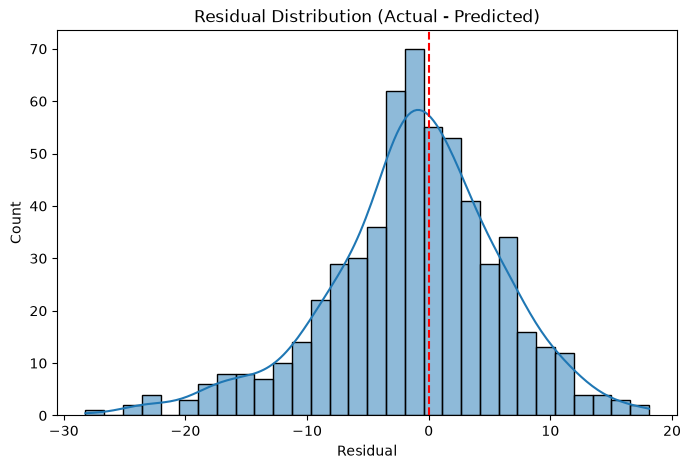

Mean residual  : -1.2612077066429914
Median residual: -0.8702418804168701
Std of residual: 7.157241631209518


In [91]:
plt.figure(figsize=(8,5))
sns.histplot(error_df["Residual"], kde=True, bins=30)
plt.axvline(0, color="red", linestyle="--")
plt.title("Residual Distribution (Actual - Predicted)")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

print("Mean residual  :", error_df["Residual"].mean())
print("Median residual:", error_df["Residual"].median())
print("Std of residual:", error_df["Residual"].std())

Residuals vs Predicted Values

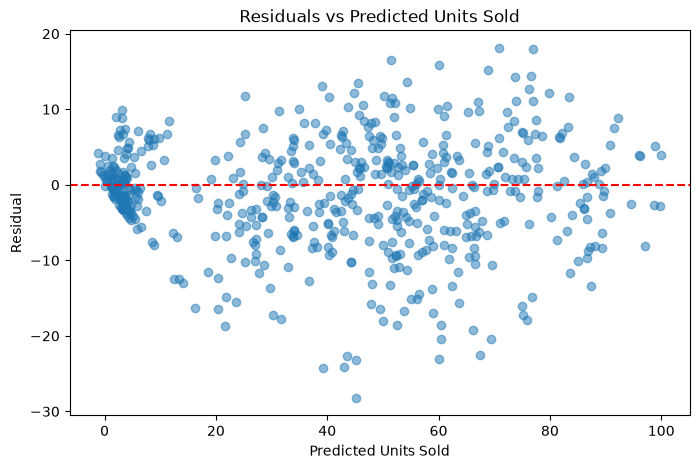

In [92]:
plt.figure(figsize=(8,5))
plt.scatter(error_df["Predicted"], error_df["Residual"], alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals vs Predicted Units Sold")
plt.xlabel("Predicted Units Sold")
plt.ylabel("Residual")
plt.show()

Error Over Time

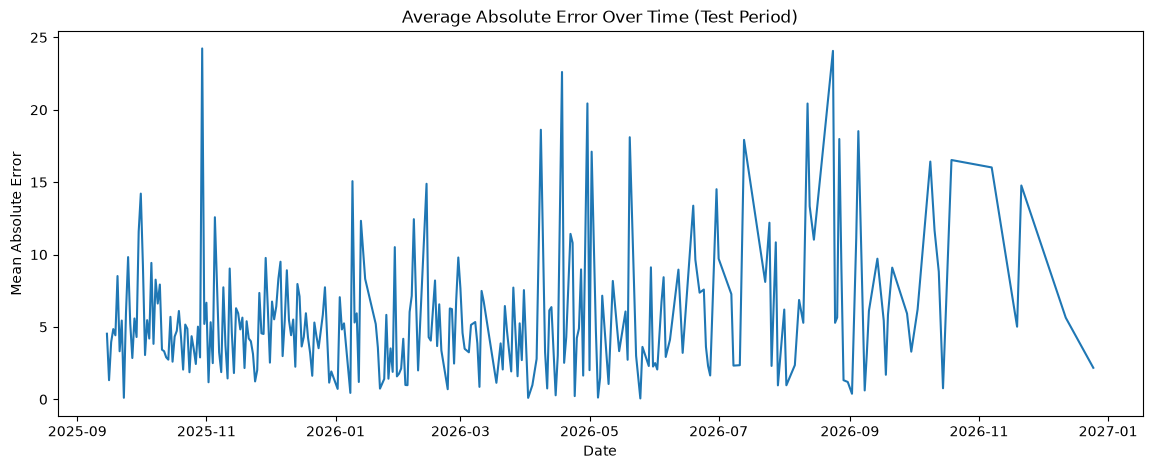

In [93]:
error_over_time = error_df.groupby("Date")["Abs_Error"].mean()

plt.figure(figsize=(14,5))
plt.plot(error_over_time.index, error_over_time.values)
plt.title("Average Absolute Error Over Time (Test Period)")
plt.xlabel("Date")
plt.ylabel("Mean Absolute Error")
plt.show()

Error by Product / Category / Store

`Product_ID`, `Category`, and `Store_ID` were one-hot encoded during feature engineering, so the labels are recovered here from the dummy columns to make the error breakdown readable.

In [94]:
def reverse_one_hot(source_df, index, prefix):
    """Recover the original category label from one-hot dummy columns for the given row index."""
    cols = [c for c in source_df.columns if c.startswith(prefix)]
    sub = source_df.loc[index, cols]
    return sub.idxmax(axis=1).str.replace(prefix, "", regex=False)

error_df["Category"] = reverse_one_hot(df, test_index, "Category_").values
error_df["Product_Name"] = reverse_one_hot(df, test_index, "Product_Name_").values
error_df["Store_ID"] = reverse_one_hot(df, test_index, "Store_ID_").values

error_df.head()

,Date,Actual,Predicted,Residual,Abs_Error,Pct_Error,Category,Product_Name,Store_ID
0,2025-09-15,11,6.467554,4.532446,4.532446,41.204058,Appliances,Coffee Maker,S03
1,2025-09-16,60,60.018852,-0.018852,0.018852,0.031420,Stationery,Notebook Pack,S01
2,2025-09-16,56,53.374435,2.625565,2.625565,4.688508,Electronics,Bluetooth Speaker,S04
3,2025-09-17,87,90.768120,-3.768120,3.768120,4.331172,Furniture,Office Chair,S01
4,2025-09-17,1,3.146327,-2.146327,2.146327,214.632702,Sports,Yoga Mat,S03


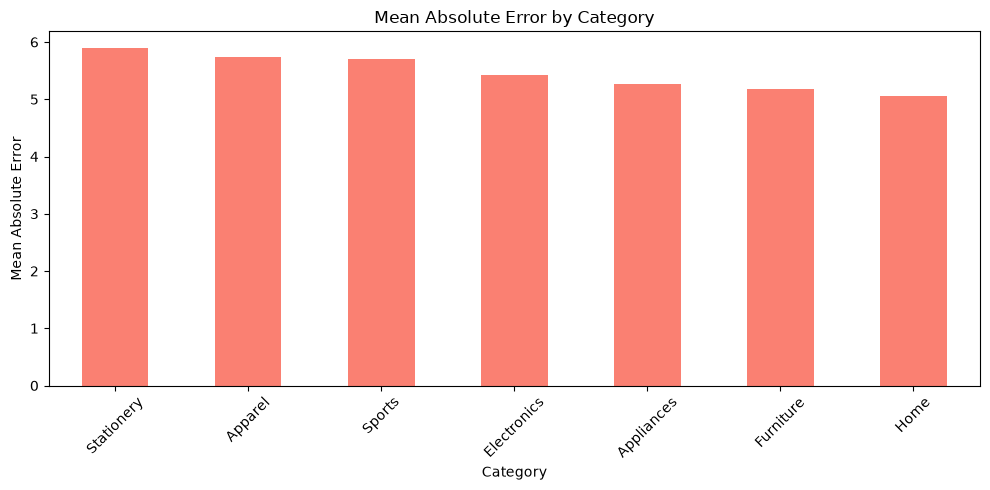

In [95]:
category_error = (
    error_df.groupby("Category")["Abs_Error"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
category_error.plot(kind="bar", color="salmon")
plt.title("Mean Absolute Error by Category")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

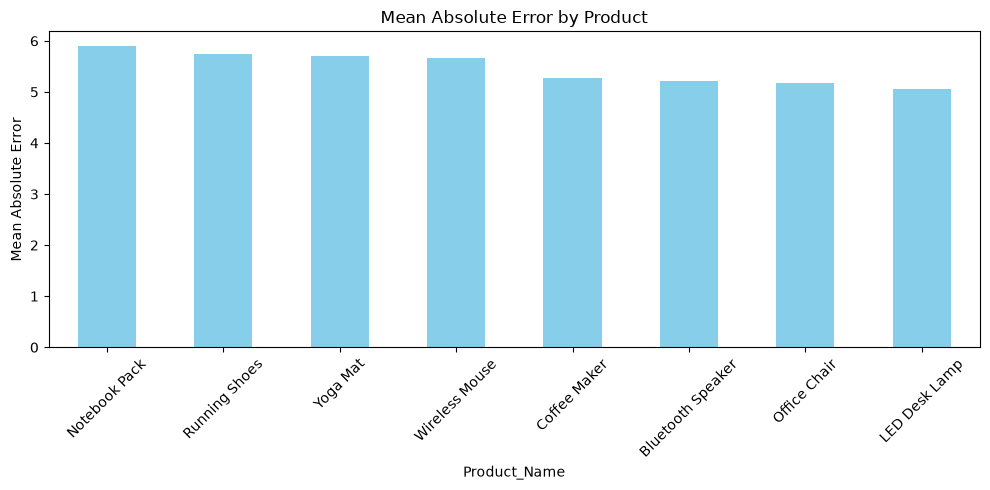

In [96]:
product_error = (
    error_df.groupby("Product_Name")["Abs_Error"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
product_error.plot(kind="bar", color="skyblue")
plt.title("Mean Absolute Error by Product")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Largest Individual Errors

In [97]:
worst_errors = error_df.sort_values("Abs_Error", ascending=False).head(15)
worst_errors[["Date", "Product_Name", "Category", "Store_ID", "Actual", "Predicted", "Abs_Error", "Pct_Error"]]

,Date,Product_Name,Category,Store_ID,Actual,Predicted,Abs_Error,Pct_Error
574,2026-11-21,Notebook Pack,Stationery,S03,17,45.224110,28.224110,166.024174
145,2025-10-30,Office Chair,Furniture,S02,15,39.237507,24.237507,161.583379
542,2026-08-24,Bluetooth Speaker,Electronics,S01,19,43.069439,24.069439,126.681258
256,2025-12-09,Notebook Pack,Stationery,S03,22,45.254463,23.254463,105.702105
498,2026-05-30,Coffee Maker,Appliances,S02,37,60.126797,23.126797,62.504856
456,2026-04-18,Notebook Pack,Stationery,S03,21,43.610958,22.610958,107.671229
39,2025-09-25,Wireless Mouse,Electronics,S03,45,67.507233,22.507233,50.016073
469,2026-04-30,Coffee Maker,Appliances,S02,40,60.438431,20.438431,51.096077
539,2026-08-12,Office Chair,Furniture,S01,49,69.433037,20.433037,41.700075
59,2025-10-01,Notebook Pack,Stationery,S02,47,66.215561,19.215561,40.884172


# 10. Walk-Forward Validation

A single 80/20 split only tells us how the model does on one block of future data. Walk-forward validation repeats the same idea across several rolling blocks — retraining on an expanding history and testing on the next unseen chunk each time — using the best hyperparameters found earlier (`random_search.best_params_`). This shows whether XGBoost's accuracy is stable over time or degrades in some periods.

In [ ]:
best_params_xgb = random_search.best_params_

n_splits_wf = 5
test_block_size = int(len(X_train) * 0.10)

wf_tscv = TimeSeriesSplit(n_splits=n_splits_wf, test_size=test_block_size)

wf_results = []

for fold, (train_idx, test_idx) in enumerate(wf_tscv.split(X_train), start=1):
    X_tr, X_te = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_tr, y_te = y_train.iloc[train_idx], y_train.iloc[test_idx]

    model_fold = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        **best_params_xgb
    )
    model_fold.fit(X_tr, y_tr)
    pred_fold = model_fold.predict(X_te)

    fold_mae = mean_absolute_error(y_te, pred_fold)
    fold_rmse = np.sqrt(mean_squared_error(y_te, pred_fold))
    fold_r2 = r2_score(y_te, pred_fold)

    wf_results.append({
        "Fold": fold,
        "Train_Size": len(train_idx),
        "Test_Size": len(test_idx),
        "MAE": fold_mae,
        "RMSE": fold_rmse,
        "R2": fold_r2
    })

    print(f"Fold {fold}: MAE={fold_mae:.3f}  RMSE={fold_rmse:.3f}  R2={fold_r2:.3f}")

wf_results_df = pd.DataFrame(wf_results)
wf_results_df

Fold 1: MAE=5.253  RMSE=7.320  R2=0.936
Fold 2: MAE=5.282  RMSE=7.289  R2=0.938
Fold 3: MAE=5.338  RMSE=7.413  R2=0.931
Fold 4: MAE=5.379  RMSE=6.963  R2=0.940
Fold 5: MAE=4.737  RMSE=6.390  R2=0.950


,Fold,Train_Size,Test_Size,MAE,RMSE,R2
0,1,1448,288,5.253006,7.320461,0.935884
1,2,1736,288,5.282160,7.288791,0.937971
2,3,2024,288,5.337876,7.412642,0.931308
3,4,2312,288,5.379492,6.963216,0.940407
4,5,2600,288,4.737265,6.389907,0.949804


Stability Check Across Folds

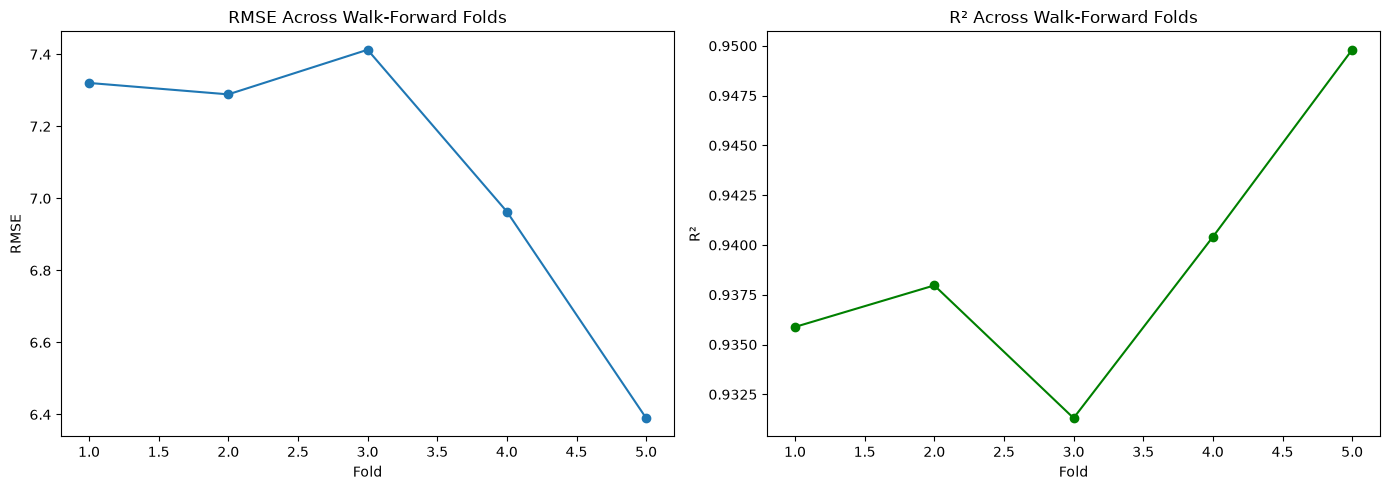

Mean RMSE across folds: 7.075003205374822 | Std: 0.4188699019986483
Mean R² across folds  : 0.9390748023986817 | Std: 0.006866774395134059


In [99]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(wf_results_df["Fold"], wf_results_df["RMSE"], marker="o")
axes[0].set_title("RMSE Across Walk-Forward Folds")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("RMSE")

axes[1].plot(wf_results_df["Fold"], wf_results_df["R2"], marker="o", color="green")
axes[1].set_title("R\u00b2 Across Walk-Forward Folds")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("R\u00b2")

plt.tight_layout()
plt.show()

print("Mean RMSE across folds:", wf_results_df["RMSE"].mean(), "| Std:", wf_results_df["RMSE"].std())
print("Mean R\u00b2 across folds  :", wf_results_df["R2"].mean(), "| Std:", wf_results_df["R2"].std())

# 11. Final XGBoost Retraining

Walk-forward validation confirmed the model generalizes across different time periods, so the version that actually gets deployed is retrained on **all** available data (train + test combined) using the same tuned hyperparameters — this squeezes out the extra signal in the held-out 20% instead of throwing it away. `best_xgb` (trained on 80%) stays as-is for the honest evaluation numbers reported earlier; `final_xgb_model` below is the one that gets saved and deployed.

In [146]:
final_xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    **best_params_xgb
)

final_xgb_model.fit(X_train, y_train)

print("Final model retrained on full dataset:", X_train.shape)

Final model retrained on full dataset: (2310, 91)


# 12. Real / Future Sales Prediction

**Important assumption up front:** the engineered features include things nobody actually knows in advance — future `Price`, `Promotion_Flag`, `Weather`, `Discount_Percentage`, `Marketing_Spend`, etc. There is no way around this for a model trained this way: the function below carries forward each product/store's most recently known value for those business inputs by default, and exposes an `overrides` dict so you can plug in a planned promotion, price change, or marketing spend instead of the naive carry-forward guess. Date-derived features (weekday, month, cyclical encodings, etc.) are always computed exactly from the target date. Lag/rolling/average features are updated recursively — each predicted day is fed back in as history for the next day, exactly like the training-time features were built (lag/rolling are per `Product_ID`, matching how they were engineered; `Store_Avg_Units_Sold` is per `Store_ID`).

Check Available Product / Store Codes

In [147]:
FEATURE_COLUMNS = X_train.columns.tolist()

product_ids = [c.replace("Product_ID_", "") for c in df.columns if c.startswith("Product_ID_")]
store_ids = [c.replace("Store_ID_", "") for c in df.columns if c.startswith("Store_ID_")]

print("Available Product IDs:", product_ids)
print("Available Store IDs  :", store_ids)

Available Product IDs: ['P001', 'P002', 'P003', 'P004', 'P005', 'P006', 'P007', 'P008']
Available Store IDs  : ['S01', 'S02', 'S03', 'S04']


Future Row Builder

In [102]:
STATIC_PREFIXES = [
    "Product_ID_", "Product_Name_", "Category_", "Store_ID_", "Store_Location_",
    "Holiday_Name_", "Season_", "Weather_", "Sales_Channel_", "Customer_Segment_"
]

def build_future_row(date, product_history, store_history, template_row, overrides=None):
    """Builds one future feature row matching FEATURE_COLUMNS, for a single date."""
    overrides = overrides or {}
    row = {}

    # ---- Date-derived features: always computed exactly, never assumed ----
    row["Year"] = date.year
    row["Month"] = date.month
    row["Day"] = date.day
    row["Day_of_Week"] = date.dayofweek
    row["Week_of_Year"] = int(date.isocalendar().week)
    row["Day_of_Year"] = date.dayofyear
    row["Is_Weekend"] = int(date.dayofweek >= 5)
    row["Is_Month_Start"] = int(date.is_month_start)
    row["Is_Month_End"] = int(date.is_month_end)
    row["Quarter"] = (date.month - 1) // 3 + 1
    row["Month_Sin"] = np.sin(2 * np.pi * date.month / 12)
    row["Month_Cos"] = np.cos(2 * np.pi * date.month / 12)
    row["Day_Sin"] = np.sin(2 * np.pi * date.dayofweek / 7)
    row["Day_Cos"] = np.cos(2 * np.pi * date.dayofweek / 7)

    # ---- Business/exogenous features: carry forward last known value unless overridden ----
    exogenous_defaults = {
        "Price": template_row["Price"],
        "Discount_Percentage": template_row["Discount_Percentage"],
        "Promotion_Flag": template_row["Promotion_Flag"],
        "Stock_Availability": template_row["Stock_Availability"],
        "Holiday_Flag": 0,
        "Local_Event_Flag": 0,
        "Competitor_Price": template_row["Competitor_Price"],
        "Economic_Indicator": template_row["Economic_Indicator"],
        "Marketing_Spend": template_row["Marketing_Spend"],
    }
    exogenous_defaults.update(overrides)
    row.update(exogenous_defaults)

    row["Price_Difference"] = row["Price"] - row["Competitor_Price"]
    row["Price_Ratio"] = row["Price"] / (row["Competitor_Price"] + 1e-6)
    row["Discount_Amount"] = row["Price"] * row["Discount_Percentage"] / 100
    row["Holiday_Weekend"] = row["Holiday_Flag"] * row["Is_Weekend"]

    # ---- Lag / rolling / average features from recursively updated history ----
    hist = product_history
    row["Units_Sold_Lag_1"] = hist[-1] if len(hist) >= 1 else 0
    row["Units_Sold_Lag_7"] = hist[-7] if len(hist) >= 7 else row["Units_Sold_Lag_1"]
    row["Units_Sold_Lag_14"] = hist[-14] if len(hist) >= 14 else row["Units_Sold_Lag_1"]

    last7 = hist[-7:] if hist else []
    last14 = hist[-14:] if hist else []
    row["Rolling_Mean_7"] = np.mean(last7) if last7 else 0
    row["Rolling_Mean_14"] = np.mean(last14) if last14 else 0
    row["Rolling_7_Max"] = np.max(last7) if last7 else 0
    row["Rolling_7_Min"] = np.min(last7) if last7 else 0
    row["Rolling_7_Std"] = np.std(last7, ddof=1) if len(last7) > 1 else 0.0

    row["Product_Avg_Units_Sold"] = np.mean(hist) if hist else 0
    row["Store_Avg_Units_Sold"] = np.mean(store_history) if store_history else 0

    # ---- Static identity dummies: copied from the product/store's own historical template ----
    for col in FEATURE_COLUMNS:
        if any(col.startswith(p) for p in STATIC_PREFIXES):
            row[col] = template_row[col]

    return {col: row.get(col, template_row.get(col, 0)) for col in FEATURE_COLUMNS}

Recursive Multi-Day Forecast Function

In [103]:
def forecast_future_sales(model, source_df, product_id, store_id, forecast_days=14,
                           overrides=None, start_date=None):
    """
    Recursively forecasts Units_Sold for `forecast_days` days ahead for one Product_ID + Store_ID.
    Each day's prediction is appended back into the history so the next day's lag/rolling features
    reflect it, mirroring how the training-time features were engineered.
    """
    product_col = f"Product_ID_{product_id}"
    store_col = f"Store_ID_{store_id}"

    if product_col not in source_df.columns or store_col not in source_df.columns:
        raise ValueError("Unknown product_id or store_id — check available codes above.")

    combo_history_df = source_df.loc[
        (source_df[product_col] == 1) & (source_df[store_col] == 1)
    ].sort_values("Date")

    if combo_history_df.empty:
        raise ValueError(f"No historical rows found for Product_ID={product_id}, Store_ID={store_id}")

    template_row = combo_history_df.iloc[-1]

    # Product-level history (Lag/Rolling features were engineered per Product_ID only)
    product_history = source_df.loc[source_df[product_col] == 1].sort_values("Date")["Units_Sold"].tolist()

    # Store-level history (Store_Avg_Units_Sold was engineered per Store_ID only)
    store_history = source_df.loc[source_df[store_col] == 1].sort_values("Date")["Units_Sold"].tolist()

    if start_date is None:
        start_date = source_df["Date"].max() + pd.Timedelta(days=1)

    future_dates = pd.date_range(start=start_date, periods=forecast_days, freq="D")

    predictions = []

    for date in future_dates:
        row_dict = build_future_row(date, product_history, store_history, template_row, overrides)
        X_future = pd.DataFrame([row_dict])[FEATURE_COLUMNS]

        pred = model.predict(X_future)[0]
        pred = max(0.0, float(pred))  # sales can't be negative

        predictions.append({"Date": date, "Predicted_Units_Sold": pred})

        product_history.append(pred)
        store_history.append(pred)

    return pd.DataFrame(predictions)

Example: 30-Day Forecast

In [104]:
example_product_id = product_ids[0]
example_store_id = store_ids[0]

future_preds = forecast_future_sales(
    model=final_xgb_model,
    source_df=df,
    product_id=example_product_id,
    store_id=example_store_id,
    forecast_days=30
)

future_preds

,Date,Predicted_Units_Sold
0,2026-12-26,57.499496
1,2026-12-27,58.762726
2,2026-12-28,57.566280
3,2026-12-29,59.473705
4,2026-12-30,58.295273
5,2026-12-31,59.460106
6,2027-01-01,56.699810
7,2027-01-02,57.814907
8,2027-01-03,57.270115
9,2027-01-04,56.012665


Plot: Recent Actual vs Future Forecast

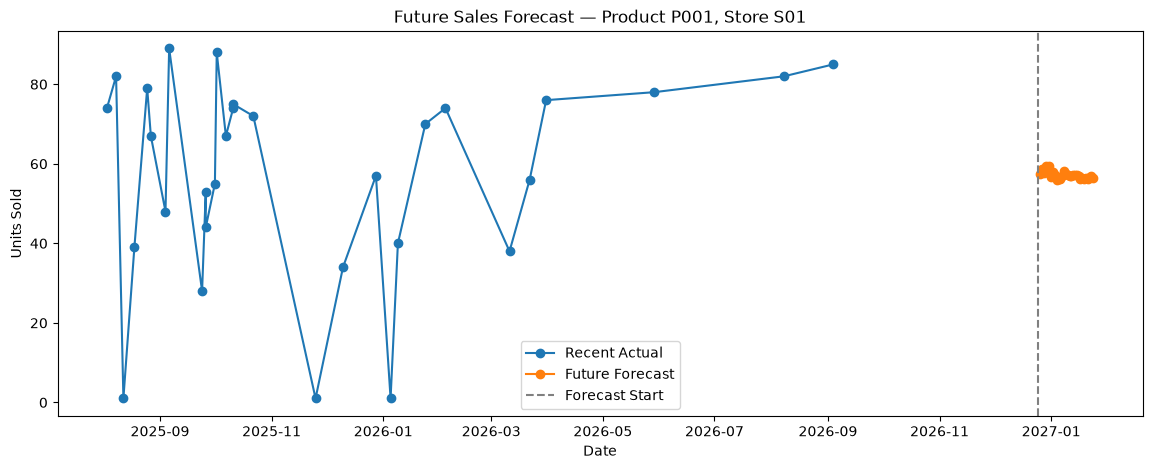

In [105]:
product_col_ex = f"Product_ID_{example_product_id}"
store_col_ex = f"Store_ID_{example_store_id}"

recent_actual = df.loc[
    (df[product_col_ex] == 1) & (df[store_col_ex] == 1)
].sort_values("Date")[["Date", "Units_Sold"]].tail(30)

plt.figure(figsize=(14,5))
plt.plot(recent_actual["Date"], recent_actual["Units_Sold"], label="Recent Actual", marker="o")
plt.plot(future_preds["Date"], future_preds["Predicted_Units_Sold"], label="Future Forecast", marker="o")
plt.axvline(df["Date"].max(), color="gray", linestyle="--", label="Forecast Start")
plt.title(f"Future Sales Forecast — Product {example_product_id}, Store {example_store_id}")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.show()

Scenario Example: Simulating a Promotion

To test a business scenario (e.g. "what if we run a promotion at 20% off for the next two weeks"), pass an `overrides` dict instead of relying on the carried-forward defaults.

In [106]:
promo_overrides = {
    "Promotion_Flag": 1,
    "Discount_Percentage": 20
}

promo_forecast = forecast_future_sales(
    model=final_xgb_model,
    source_df=df,
    product_id=example_product_id,
    store_id=example_store_id,
    forecast_days=14,
    overrides=promo_overrides
)

promo_forecast

,Date,Predicted_Units_Sold
0,2026-12-26,85.600586
1,2026-12-27,85.517387
2,2026-12-28,85.562660
3,2026-12-29,85.547668
4,2026-12-30,85.451843
5,2026-12-31,84.526634
6,2027-01-01,82.964577
7,2027-01-02,83.407722
8,2027-01-03,83.516968
9,2027-01-04,82.565620


# 13. Save Model

Saves everything the deployed app needs: the trained model, the exact feature column order (XGBoost is order-sensitive), and a compact history table so `forecast_future_sales` can be reused as-is inside Streamlit without re-running the whole feature engineering pipeline.

In [148]:
# !pip install joblib --quiet

import joblib

joblib.dump(final_xgb_model, "final_xgb_model.pkl")
joblib.dump(FEATURE_COLUMNS, "feature_columns.pkl")

history_cols = (
    ["Date", "Units_Sold", "Price", "Competitor_Price", "Discount_Percentage",
     "Promotion_Flag", "Stock_Availability", "Economic_Indicator", "Marketing_Spend"]
    + [c for c in df.columns if any(
          c.startswith(p) for p in
          ["Product_ID_", "Store_ID_", "Product_Name_", "Category_",
           "Store_Location_", "Holiday_Name_", "Season_", "Weather_",
           "Sales_Channel_", "Customer_Segment_"]
      )]
)

deployment_history = df[history_cols].copy()
deployment_history.to_pickle("deployment_history.pkl")

print("Saved: final_xgb_model.pkl, feature_columns.pkl, deployment_history.pkl")

Saved: final_xgb_model.pkl, feature_columns.pkl, deployment_history.pkl
